<a href="https://colab.research.google.com/github/Ayyjinx/SCIT-Projects/blob/main/Fraud_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IEEE-CIS Fraud Detection: Fraud Analytics


**Objective:**  
To perform exploratory data analysis, fraud-oriented feature engineering, supervised machine learning, and anomaly detection on the IEEE-CIS Fraud Detection dataset to identify patterns associated with fraudulent transactions.

### Dataset
IEEE-CIS Fraud Detection Dataset

### Methodology

EDA  
↓  
Fraud-Oriented Feature Engineering  
↓  
Leakage-Safe Train/Validation Split  
↓  
XGBoost + CatBoost  
↓  
Supervised Probability Ensemble  
↓  
Threshold & Error Analysis  
↓  
Isolation Forest  
↓  
Supervised Risk × Anomaly Analysis  
↓  
Final Fraud Analytics Findings




In [1]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install xgboost catboost  shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from sklearn.ensemble import IsolationForest

# Models
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Explainability
import shap

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# CHECK COLAB GPU
# ============================================================

!nvidia-smi

Wed Sep 23 06:33:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# ============================================================
# IEEE-CIS FRAUD DETECTION
# MEMORY-OPTIMIZED DATA LOADING + MERGING
# ============================================================

import pandas as pd
import numpy as np
import gc
import os
import psutil

# ------------------------------------------------------------
# MEMORY HELPER
# ------------------------------------------------------------

process = psutil.Process(os.getpid())

def memory_report(label):
    process_ram = process.memory_info().rss / 1024**3

    print(f"\n{'=' * 60}")
    print(f"{label}")
    print(f"{'=' * 60}")
    print(f"Python process RAM : {process_ram:.2f} GB")

    if "train_transaction" in globals():
        print(
            f"Transaction RAM    : "
            f"{train_transaction.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
        )

    if "train_identity" in globals():
        print(
            f"Identity RAM       : "
            f"{train_identity.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
        )

    if "train" in globals():
        print(
            f"Merged train RAM   : "
            f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
        )


# ============================================================
# 1. LOAD TRANSACTION DATA
# ============================================================

print("\nLoading transaction data...")

train_transaction = pd.read_csv(
    "/content/drive/MyDrive/train_transaction.csv",
    low_memory=False
)

print("Transaction shape:", train_transaction.shape)

memory_report("After loading transaction")


# ============================================================
# 2. OPTIMIZE TRANSACTION NUMERIC COLUMNS
# ============================================================

print("\nOptimizing transaction numeric columns...")

# float64 -> float32
float_cols = train_transaction.select_dtypes(
    include=["float64"]
).columns

for col in float_cols:
    train_transaction[col] = train_transaction[col].astype(np.float32)


# ============================================================
# 3. OPTIMIZE TRANSACTION CATEGORICAL COLUMNS
# ============================================================

transaction_categorical_cols = [
    "ProductCD",
    "card4",
    "card6",
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9"
]

for col in transaction_categorical_cols:
    if col in train_transaction.columns:
        train_transaction[col] = train_transaction[col].astype("category")


gc.collect()

memory_report("After optimizing transaction")


# ============================================================
# 4. LOAD IDENTITY DATA
# ============================================================

print("\nLoading identity data...")

train_identity = pd.read_csv(
    "/content/drive/MyDrive/train_identity.csv",
    low_memory=False
)

print("Identity shape:", train_identity.shape)

memory_report("After loading identity")


# ============================================================
# 5. OPTIMIZE IDENTITY NUMERIC COLUMNS
# ============================================================

print("\nOptimizing identity numeric columns...")

identity_float_cols = train_identity.select_dtypes(
    include=["float64"]
).columns

for col in identity_float_cols:
    train_identity[col] = train_identity[col].astype(np.float32)


# ============================================================
# 6. OPTIMIZE IDENTITY CATEGORICAL COLUMNS
# ============================================================

print("\nOptimizing identity categorical columns...")

identity_object_cols = train_identity.select_dtypes(
    include=["object"]
).columns

for col in identity_object_cols:
    train_identity[col] = train_identity[col].astype("category")


gc.collect()

memory_report("After optimizing identity")


# ============================================================
# 7. CHECK TRANSACTION IDs BEFORE MERGE
# ============================================================

print("\nChecking TransactionID integrity...")

print(
    "Transaction duplicate IDs:",
    train_transaction["TransactionID"].duplicated().sum()
)

print(
    "Identity duplicate IDs:",
    train_identity["TransactionID"].duplicated().sum()
)


# ============================================================
# 8. MERGE TRANSACTION + IDENTITY
# ============================================================

print("\nMerging transaction and identity data...")

train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left",
    validate="one_to_one"
)

print("Merged dataset shape:", train.shape)


# ============================================================
# 9. REMOVE SOURCE DATAFRAMES
# ============================================================

del train_transaction
del train_identity

gc.collect()


# ============================================================
# 10. FINAL MEMORY REPORT
# ============================================================

memory_report("FINAL MERGED DATASET")


# ============================================================
# 11. BASIC VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

print(
    "Duplicate TransactionID:",
    train["TransactionID"].duplicated().sum()
)

print(
    "Fraud distribution:"
)

print(
    train["isFraud"].value_counts()
)

print(
    "\nFraud percentage:"
)

print(
    train["isFraud"].value_counts(normalize=True) * 100
)

print(
    "\nFinal DataFrame memory:",
    f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)


Loading transaction data...
Transaction shape: (590540, 394)

After loading transaction
Python process RAM : 2.36 GB
Transaction RAM    : 2.01 GB

Optimizing transaction numeric columns...

After optimizing transaction
Python process RAM : 1.56 GB
Transaction RAM    : 0.90 GB

Loading identity data...
Identity shape: (144233, 41)

After loading identity
Python process RAM : 1.69 GB
Transaction RAM    : 0.90 GB
Identity RAM       : 0.14 GB

Optimizing identity numeric columns...

Optimizing identity categorical columns...

After optimizing identity
Python process RAM : 1.58 GB
Transaction RAM    : 0.90 GB
Identity RAM       : 0.02 GB

Checking TransactionID integrity...
Transaction duplicate IDs: 0
Identity duplicate IDs: 0

Merging transaction and identity data...
Merged dataset shape: (590540, 434)

FINAL MERGED DATASET
Python process RAM : 3.24 GB
Merged train RAM   : 0.96 GB

FINAL DATASET VALIDATION
Rows: 590540
Columns: 434
Duplicate TransactionID: 0
Fraud distribution:
isFraud
0

In [5]:
# ============================================================
# VERIFY MERGED DATASET
# ============================================================

print("=" * 60)
print("MERGE VERIFICATION")
print("=" * 60)

print(f"Rows: {train.shape[0]:,}")
print(f"Columns: {train.shape[1]:,}")

print("\nDuplicate TransactionIDs:")
print(train["TransactionID"].duplicated().sum())

print("\nTransactionID range:")
print("Min:", train["TransactionID"].min())
print("Max:", train["TransactionID"].max())

print("\nTarget column:")
print("isFraud" in train.columns)

print("\nIdentity columns successfully merged:")
identity_columns = [col for col in train.columns if col.startswith("id_")]
print(f"{len(identity_columns)} identity columns found")

print("\nMissing identity records:")
identity_missing = train["id_01"].isna().sum()

print(f"Missing identity: {identity_missing:,}")
print(
    f"Available identity: "
    f"{len(train) - identity_missing:,}"
)

print(
    f"Identity available: "
    f"{(1 - identity_missing / len(train)) * 100:.2f}%"
)

MERGE VERIFICATION
Rows: 590,540
Columns: 434

Duplicate TransactionIDs:
0

TransactionID range:
Min: 2987000
Max: 3577539

Target column:
True

Identity columns successfully merged:
38 identity columns found

Missing identity records:
Missing identity: 446,307
Available identity: 144,233
Identity available: 24.42%


In [6]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target_counts = train["isFraud"].value_counts().sort_index()
target_percent = train["isFraud"].value_counts(
    normalize=True
).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

target_summary.index = ["Legitimate", "Fraud"]

display(target_summary)

,Count,Percentage
Legitimate,569877,96.5
Fraud,20663,3.5


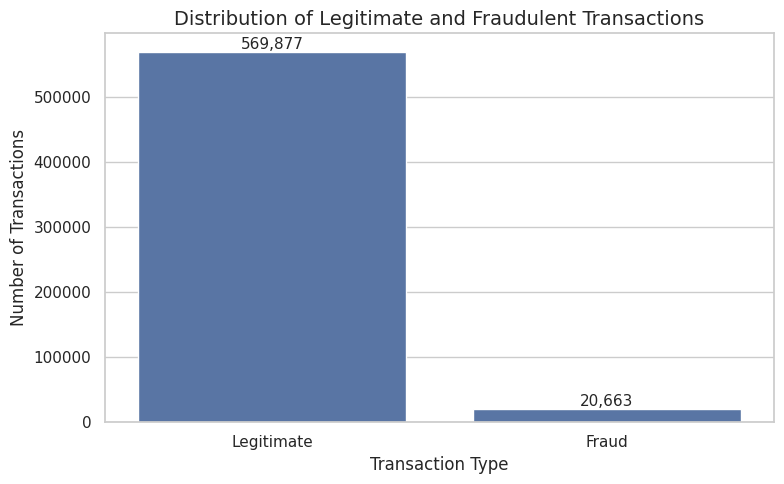

In [7]:
# ============================================================
# FRAUD DISTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fraud_plot = pd.DataFrame({
    "Transaction Type": ["Legitimate", "Fraud"],
    "Count": [
        (train["isFraud"] == 0).sum(),
        (train["isFraud"] == 1).sum()
    ]
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fraud_plot,
    x="Transaction Type",
    y="Count"
)

plt.title("Distribution of Legitimate and Fraudulent Transactions",
          fontsize=14)

plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

# Add labels without creating large objects
for i, value in enumerate(fraud_plot["Count"]):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()
plt.close()

In [8]:
# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Rows       : {train.shape[0]:,}")
print(f"Columns    : {train.shape[1]:,}")

print("\nData types:")
print(train.dtypes.value_counts())

print("\nTarget:")
print(train["isFraud"].value_counts())

print("\nNumerical columns:")
numeric_columns = train.select_dtypes(
    include=["number"]
).columns

print(len(numeric_columns))

print("\nCategorical columns:")
categorical_columns = train.select_dtypes(
    include=["object", "category"]
).columns

print(len(categorical_columns))

print("\nDataFrame memory:")
print(
    f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)

DATASET INFORMATION
Rows       : 590,540
Columns    : 434

Data types:
float32     399
category     12
int64         4
category      4
object        2
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64

Target:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Numerical columns:
403

Categorical columns:
31

DataFrame memory:
0.96 GB


In [9]:
# ============================================================
# MISSING VALUE OVERVIEW
# ============================================================

missing_count = train.isna().sum()

missing_percent = (
    missing_count / len(train) * 100
)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
    .sort_values(
        "Missing Percentage",
        ascending=False
    )
)

print(
    f"Columns containing missing values: "
    f"{len(missing_summary)}"
)

display(
    missing_summary.head(30).round(2)
)

Columns containing missing values: 414


,Missing Count,Missing Percentage
id_24,585793,99.20
id_25,585408,99.13
id_08,585385,99.13
id_07,585385,99.13
id_21,585381,99.13
id_26,585377,99.13
id_23,585371,99.12
id_22,585371,99.12
id_27,585371,99.12
dist2,552913,93.63


EDA 1: TRANSACTION AMOUNT


,count,mean,median,std,min,max
Legitimate,569877,134.509995,68.5,239.399994,0.25,31937.390625
Fraud,20663,149.240005,75.0,232.210007,0.29,5191.000000


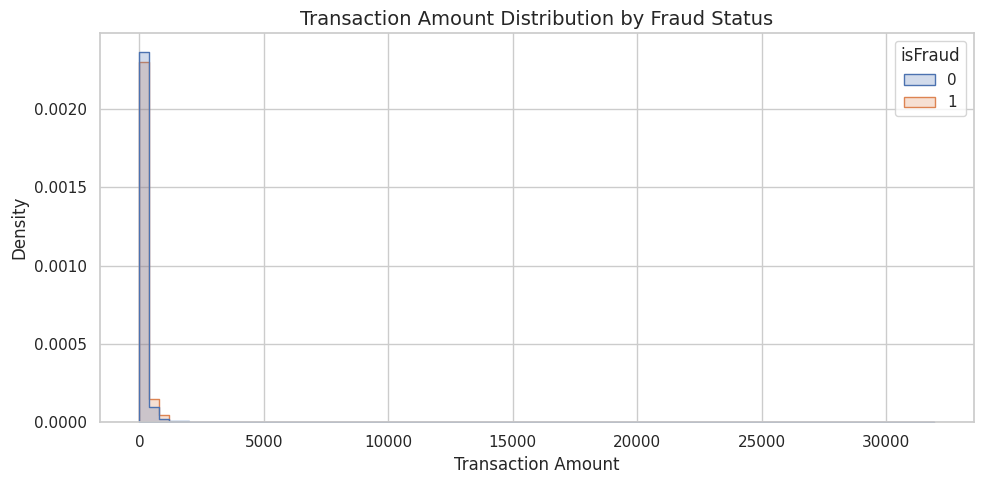

242

In [10]:
# ============================================================
# EDA 1 — TRANSACTION AMOUNT
# ============================================================

print("=" * 60)
print("EDA 1: TRANSACTION AMOUNT")
print("=" * 60)

# ------------------------------------------------------------
# FULL-DATA SUMMARY
# ------------------------------------------------------------

amount_summary = (
    train.groupby("isFraud", observed=True)["TransactionAmt"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

amount_summary.index = ["Legitimate", "Fraud"]

display(amount_summary.round(2))


# ------------------------------------------------------------
# SAMPLE FOR VISUALIZATION
# ------------------------------------------------------------

amount_plot = train[
    ["TransactionAmt", "isFraud"]
].sample(
    n=min(100_000, len(train)),
    random_state=42
)


# ------------------------------------------------------------
# HISTOGRAM
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=amount_plot,
    x="TransactionAmt",
    hue="isFraud",
    bins=80,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title(
    "Transaction Amount Distribution by Fraud Status",
    fontsize=14
)

plt.xlabel("Transaction Amount", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()


# ------------------------------------------------------------
# CLEANUP
# ------------------------------------------------------------

del amount_plot
gc.collect()

EDA 2: PRODUCT CODE


,Transactions,Fraud_Count,Fraud_Rate
ProductCD,,,
C,68519,8008,11.69
S,11628,686,5.90
H,33024,1574,4.77
R,37699,1426,3.78
W,439670,8969,2.04


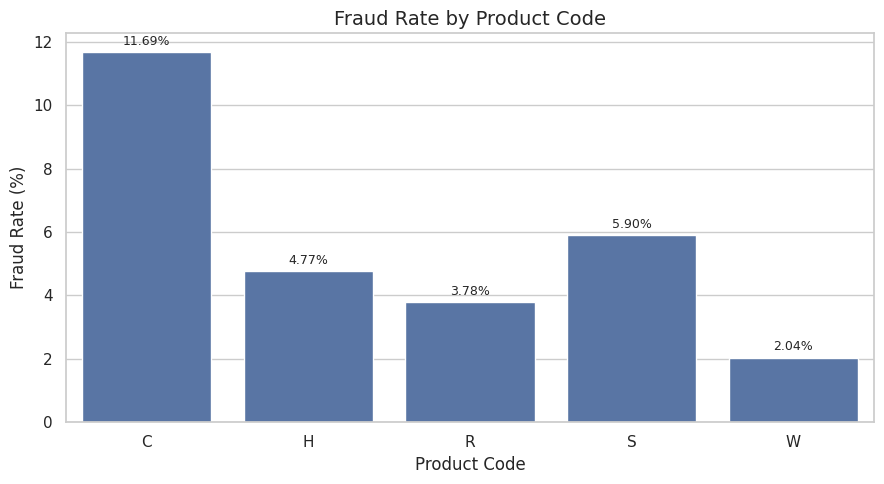

6106

In [11]:
# ============================================================
# EDA 2 — PRODUCT CODE (ProductCD)
# ============================================================

print("=" * 60)
print("EDA 2: PRODUCT CODE")
print("=" * 60)

# ------------------------------------------------------------
# FULL-DATA FRAUD RATE BY PRODUCT
# ------------------------------------------------------------

product_summary = (
    train.groupby("ProductCD", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

product_summary["Fraud_Rate"] *= 100

product_summary = product_summary.sort_values(
    "Fraud_Rate",
    ascending=False
)

display(product_summary.round(2))


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=product_summary.reset_index(),
    x="ProductCD",
    y="Fraud_Rate"
)

plt.title(
    "Fraud Rate by Product Code",
    fontsize=14
)

plt.xlabel("Product Code", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()
plt.close()

gc.collect()

EDA 3: CARD TYPE


,Transactions,Fraud_Count,Fraud_Rate
card4,,,
discover,6651,514,7.73
visa,384767,13373,3.48
mastercard,189217,6496,3.43
american express,8328,239,2.87


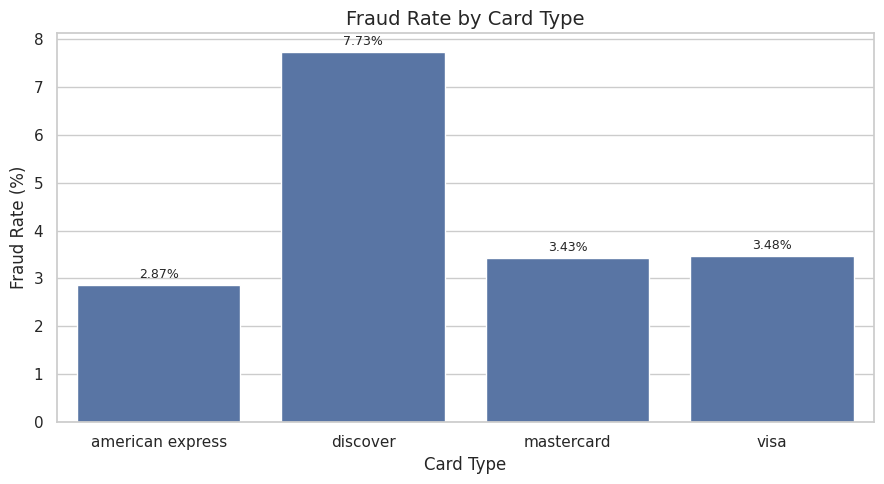

3480

In [12]:
# ============================================================
# EDA 3 — CARD TYPE (card4)
# ============================================================

print("=" * 60)
print("EDA 3: CARD TYPE")
print("=" * 60)

card4_summary = (
    train.groupby("card4", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

card4_summary["Fraud_Rate"] *= 100

card4_summary = card4_summary.sort_values(
    "Fraud_Rate",
    ascending=False
)

display(card4_summary.round(2))


# Visualization
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=card4_summary.reset_index(),
    x="card4",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Card Type", fontsize=14)
plt.xlabel("Card Type", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()
plt.close()

gc.collect()

EDA 4: CARD CATEGORY


,Transactions,Fraud_Count,Fraud_Rate
card6,,,
credit,148986,9950,6.68
debit,439938,10674,2.43
charge card,15,0,0.00
debit or credit,30,0,0.00


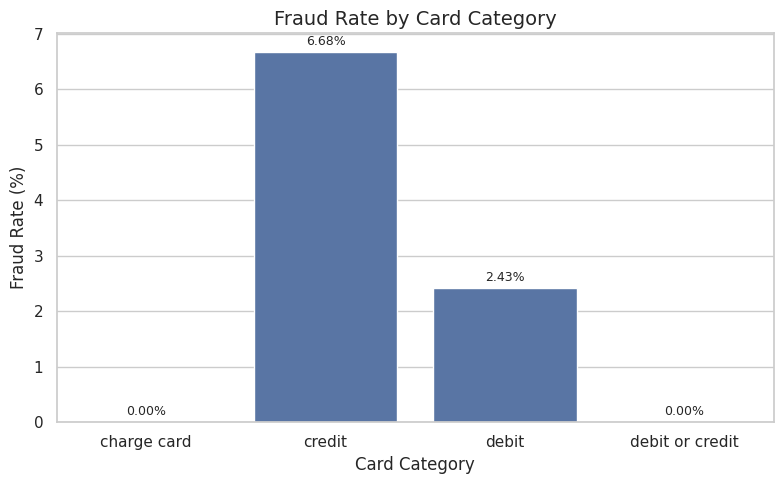

3434

In [13]:
# ============================================================
# EDA 4 — CARD CATEGORY (card6)
# ============================================================

print("=" * 60)
print("EDA 4: CARD CATEGORY")
print("=" * 60)

card6_summary = (
    train.groupby("card6", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

card6_summary["Fraud_Rate"] *= 100

card6_summary = card6_summary.sort_values(
    "Fraud_Rate",
    ascending=False
)

display(card6_summary.round(2))


plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=card6_summary.reset_index(),
    x="card6",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Card Category", fontsize=14)
plt.xlabel("Card Category", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()
plt.close()

gc.collect()

EDA 5: PURCHASER EMAIL DOMAIN
Top 15 email domains by transaction volume:


,Transactions,Fraud_Count,Fraud_Rate
P_emaildomain,,,
gmail.com,228355,9943,4.35
yahoo.com,100934,2297,2.28
hotmail.com,45250,2396,5.30
anonymous.com,36998,859,2.32
aol.com,28289,617,2.18
comcast.net,7888,246,3.12
icloud.com,6267,197,3.14
outlook.com,5096,482,9.46
msn.com,4092,90,2.20


Frequent domains with highest fraud rates:


,Transactions,Fraud_Count,Fraud_Rate
P_emaildomain,,,
mail.com,559,106,18.96
outlook.com,5096,482,9.46
live.com.mx,749,41,5.47
hotmail.com,45250,2396,5.30
gmail.com,228355,9943,4.35
icloud.com,6267,197,3.14
comcast.net,7888,246,3.12
charter.net,816,25,3.06
bellsouth.net,1909,53,2.78


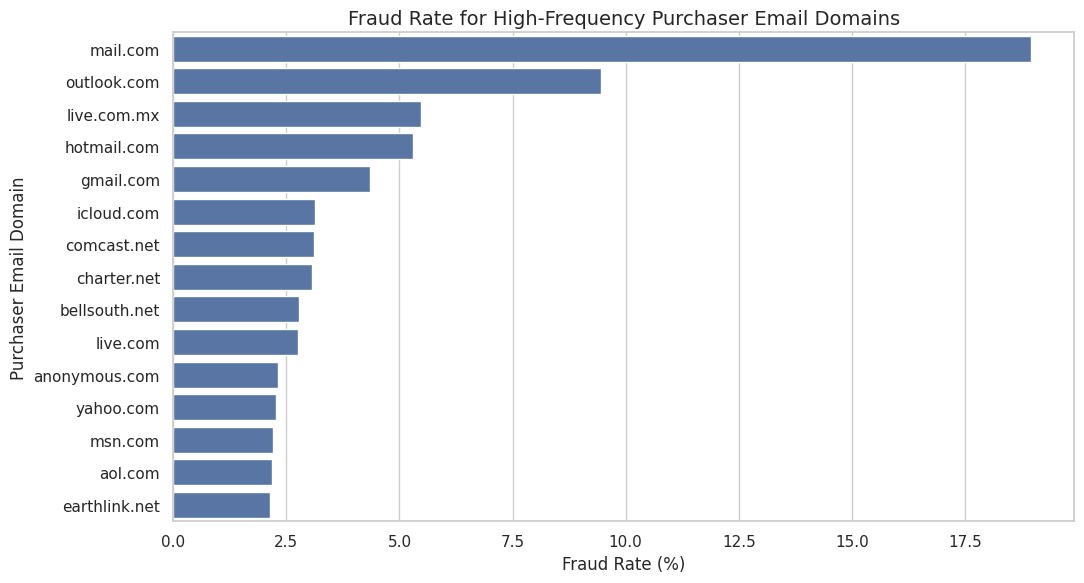

138

In [14]:
# ============================================================
# EDA 5 — PURCHASER EMAIL DOMAIN
# ============================================================

print("=" * 60)
print("EDA 5: PURCHASER EMAIL DOMAIN")
print("=" * 60)

email_summary = (
    train.groupby("P_emaildomain", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

email_summary["Fraud_Rate"] *= 100

# Top domains by transaction volume
top_email_domains = (
    email_summary
    .sort_values("Transactions", ascending=False)
    .head(15)
)

print("Top 15 email domains by transaction volume:")
display(top_email_domains.round(2))


# Domains with at least 500 transactions
frequent_email_domains = (
    email_summary[
        email_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
)

print("Frequent domains with highest fraud rates:")
display(
    frequent_email_domains.head(15).round(2)
)


# Visualization
plot_email = frequent_email_domains.head(15).reset_index()

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=plot_email,
    x="Fraud_Rate",
    y="P_emaildomain"
)

plt.title(
    "Fraud Rate for High-Frequency Purchaser Email Domains",
    fontsize=14
)

plt.xlabel("Fraud Rate (%)", fontsize=12)
plt.ylabel("Purchaser Email Domain", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

del plot_email
gc.collect()

EDA 6: RECIPIENT EMAIL DOMAIN
Transactions by recipient email availability:


,Status,Transactions,Fraud_Count,Fraud_Rate
0,Missing,453249,9436,2.08
1,Available,137291,11227,8.18


Highest fraud-rate recipient domains with >=500 transactions:


,Transactions,Fraud_Count,Fraud_Rate
R_emaildomain,,,
outlook.com,2507,414,16.51
icloud.com,1398,180,12.88
gmail.com,57147,6811,11.92
hotmail.com,27509,2140,7.78
live.com.mx,754,44,5.84
yahoo.com,11842,610,5.15
live.com,762,38,4.99
aol.com,3701,129,3.49
anonymous.com,20529,598,2.91


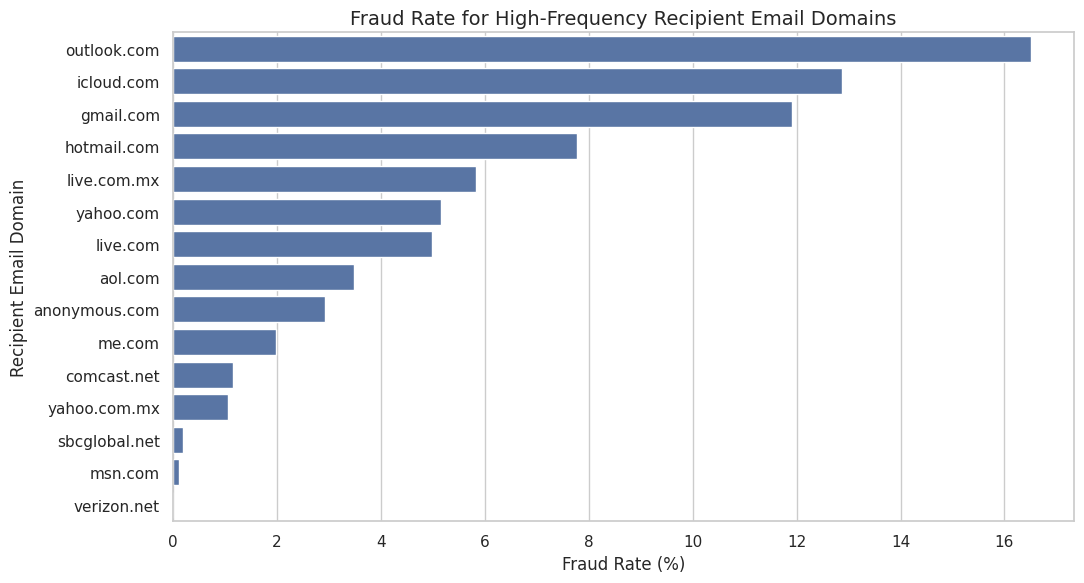

164

In [15]:
# ============================================================
# EDA 6 — RECIPIENT EMAIL DOMAIN
# ============================================================

print("=" * 60)
print("EDA 6: RECIPIENT EMAIL DOMAIN")
print("=" * 60)

r_email_summary = (
    train.groupby("R_emaildomain", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

r_email_summary["Fraud_Rate"] *= 100


# Overall availability
print("Transactions by recipient email availability:")

r_email_available = train["R_emaildomain"].notna()

availability_summary = pd.DataFrame({
    "Status": ["Missing", "Available"],
    "Transactions": [
        (~r_email_available).sum(),
        r_email_available.sum()
    ],
    "Fraud_Count": [
        train.loc[~r_email_available, "isFraud"].sum(),
        train.loc[r_email_available, "isFraud"].sum()
    ]
})

availability_summary["Fraud_Rate"] = (
    availability_summary["Fraud_Count"]
    / availability_summary["Transactions"]
    * 100
)

display(availability_summary.round(2))


# Frequent domains
frequent_r_domains = (
    r_email_summary[
        r_email_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
)

print("Highest fraud-rate recipient domains with >=500 transactions:")

display(
    frequent_r_domains.head(15).round(2)
)


# Visualization
plot_r_email = frequent_r_domains.head(15).reset_index()

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_r_email,
    x="Fraud_Rate",
    y="R_emaildomain"
)

plt.title(
    "Fraud Rate for High-Frequency Recipient Email Domains",
    fontsize=14
)

plt.xlabel("Fraud Rate (%)", fontsize=12)
plt.ylabel("Recipient Email Domain", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

del plot_r_email
gc.collect()

EDA 7: BILLING ADDRESS REGION
Address regions with >=500 transactions: 54

Highest fraud-rate regions:


,Transactions,Fraud_Count,Fraud_Rate
addr1,,,
465.0,503,42,8.35
122.0,1617,117,7.24
308.0,1279,83,6.49
324.0,2173,112,5.15
203.0,3808,155,4.07
226.0,4867,189,3.88
269.0,6404,226,3.53
512.0,8268,284,3.43
170.0,2001,68,3.40


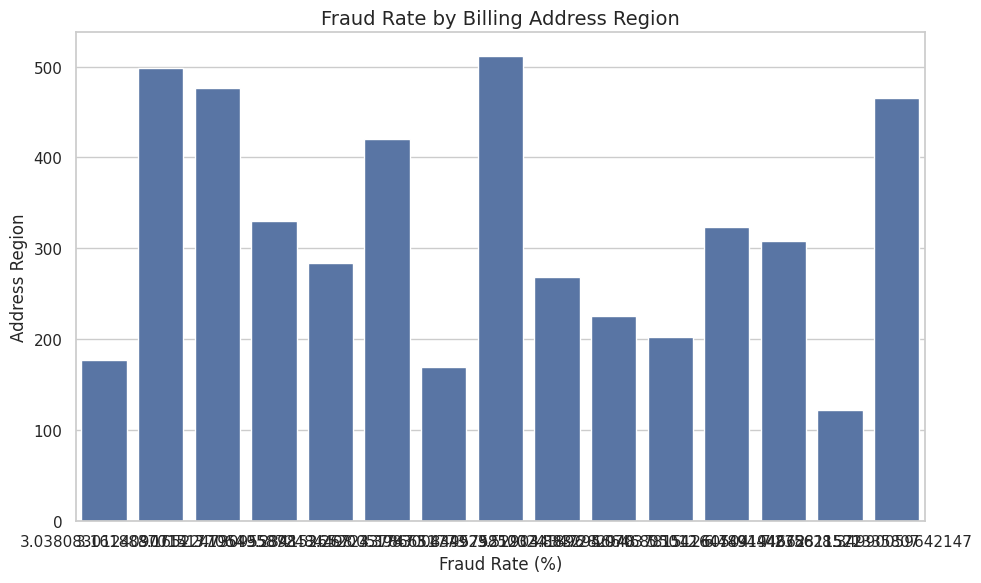

5778

In [16]:
# ============================================================
# EDA 7 — BILLING ADDRESS REGION (addr1)
# ============================================================

print("=" * 60)
print("EDA 7: BILLING ADDRESS REGION")
print("=" * 60)

addr_summary = (
    train.groupby("addr1", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

addr_summary["Fraud_Rate"] *= 100


# Keep sufficiently frequent address regions
frequent_addr = (
    addr_summary[
        addr_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
)

print(
    f"Address regions with >=500 transactions: "
    f"{len(frequent_addr)}"
)

print("\nHighest fraud-rate regions:")
display(
    frequent_addr.head(15).round(2)
)


# Visualization
plot_addr = frequent_addr.head(15).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_addr,
    x="Fraud_Rate",
    y="addr1"
)

plt.title(
    "Fraud Rate by Billing Address Region",
    fontsize=14
)

plt.xlabel("Fraud Rate (%)", fontsize=12)
plt.ylabel("Address Region", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

del plot_addr
gc.collect()

EDA 8: MATCHING VARIABLES (M1-M9)
Highest fraud-rate M-variable categories with >=500 observations:


,Variable,Category,Transactions,Fraud_Count,Fraud_Rate
8,M4,M2,59865,6809,11.37
10,M5,T,107567,4055,3.77
6,M4,M0,196405,7198,3.66
2,M2,F,33972,1184,3.49
4,M3,F,67709,2049,3.03
17,M9,F,38632,1159,3.00
7,M4,M1,52826,1429,2.71
9,M5,F,132491,3514,2.65
11,M6,F,227856,5397,2.37
14,M7,T,32901,728,2.21


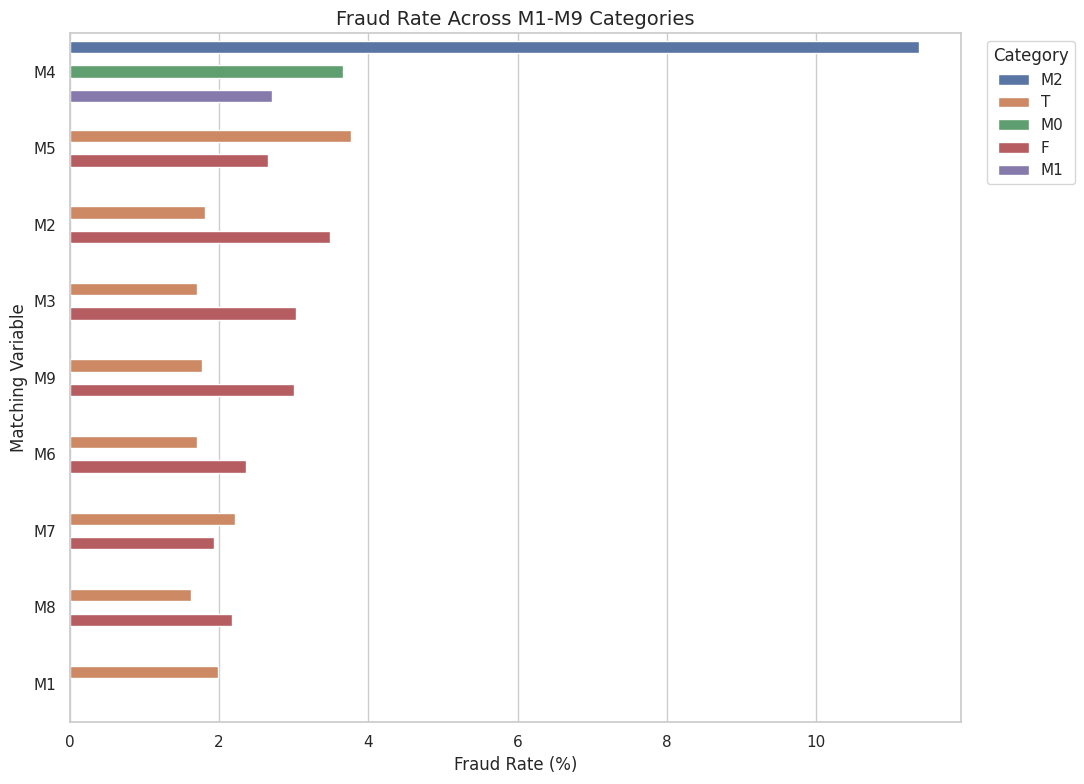

5898

In [17]:
# ============================================================
# EDA 8 — MATCHING VARIABLES M1-M9
# ============================================================

print("=" * 60)
print("EDA 8: MATCHING VARIABLES (M1-M9)")
print("=" * 60)

m_columns = [
    "M1", "M2", "M3", "M4", "M5",
    "M6", "M7", "M8", "M9"
]

m_results = []

for col in m_columns:

    summary = (
        train.groupby(col, observed=True)["isFraud"]
        .agg(
            Transactions="count",
            Fraud_Count="sum",
            Fraud_Rate="mean"
        )
    )

    summary["Fraud_Rate"] *= 100
    summary["Variable"] = col
    summary["Category"] = summary.index.astype(str)

    summary = summary.reset_index(drop=True)

    m_results.append(
        summary[
            [
                "Variable",
                "Category",
                "Transactions",
                "Fraud_Count",
                "Fraud_Rate"
            ]
        ]
    )

m_summary = pd.concat(m_results, ignore_index=True)

print("Highest fraud-rate M-variable categories with >=500 observations:")

display(
    m_summary[
        m_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
    .head(20)
    .round(2)
)


# Visualization
m_plot = (
    m_summary[
        m_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
    .head(20)
)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=m_plot,
    x="Fraud_Rate",
    y="Variable",
    hue="Category"
)

plt.title(
    "Fraud Rate Across M1-M9 Categories",
    fontsize=14
)

plt.xlabel("Fraud Rate (%)", fontsize=12)
plt.ylabel("Matching Variable", fontsize=12)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
plt.close()

del m_results
del m_summary
del m_plot

gc.collect()

EDA 9: TRANSACTION TIME


,Transactions,Fraud_Count,Fraud_Rate
Relative_Hour,,,
0,37795,1186,3.14
1,32797,1027,3.13
2,26732,1002,3.75
3,20802,797,3.83
4,14839,770,5.19
5,9701,682,7.03
6,6007,467,7.77
7,3704,393,10.61
8,2591,241,9.30


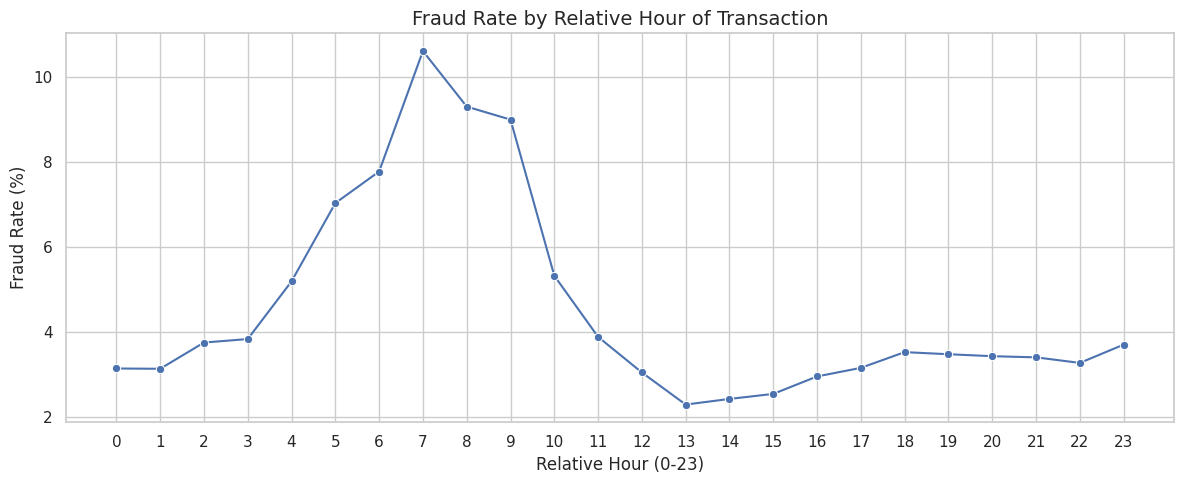


Number of relative days in dataset: 182

Highest fraud-rate relative days:


,Transactions,Fraud_Count,Fraud_Rate
Relative_Day,,,
59,2402,168,6.99
117,3042,194,6.38
73,2304,135,5.86
65,3209,183,5.70
56,2789,158,5.67
115,2461,139,5.65
129,2348,130,5.54
114,2758,150,5.44
64,4317,234,5.42


5984

In [18]:
# ============================================================
# EDA 9 — TRANSACTION TIME
# ============================================================

print("=" * 60)
print("EDA 9: TRANSACTION TIME")
print("=" * 60)

# ------------------------------------------------------------
# CREATE TEMPORARY TIME FEATURES
# ------------------------------------------------------------

transaction_dt = train["TransactionDT"]

relative_day = (
    transaction_dt // (24 * 60 * 60)
)

relative_hour = (
    (transaction_dt // (60 * 60)) % 24
)


# ------------------------------------------------------------
# FRAUD RATE BY RELATIVE HOUR
# ------------------------------------------------------------

hour_summary = pd.DataFrame({
    "Relative_Hour": relative_hour,
    "isFraud": train["isFraud"].values
})

hour_summary = (
    hour_summary
    .groupby("Relative_Hour")["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

hour_summary["Fraud_Rate"] *= 100

display(hour_summary.round(2))


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_summary.reset_index(),
    x="Relative_Hour",
    y="Fraud_Rate",
    marker="o"
)

plt.title(
    "Fraud Rate by Relative Hour of Transaction",
    fontsize=14
)

plt.xlabel(
    "Relative Hour (0-23)",
    fontsize=12
)

plt.ylabel(
    "Fraud Rate (%)",
    fontsize=12
)

plt.xticks(range(24))

plt.tight_layout()
plt.show()
plt.close()


# ------------------------------------------------------------
# RELATIVE DAY
# ------------------------------------------------------------

day_summary = pd.DataFrame({
    "Relative_Day": relative_day,
    "isFraud": train["isFraud"].values
})

day_summary = (
    day_summary
    .groupby("Relative_Day")["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

day_summary["Fraud_Rate"] *= 100

print(
    f"\nNumber of relative days in dataset: "
    f"{day_summary.shape[0]}"
)

print("\nHighest fraud-rate relative days:")

display(
    day_summary
    .sort_values("Fraud_Rate", ascending=False)
    .head(10)
    .round(2)
)

del transaction_dt
del relative_day
del relative_hour
del hour_summary
del day_summary

gc.collect()

EDA 10: DEVICE TYPE


,Transactions,Fraud_Count,Fraud_Rate
DeviceType,,,
mobile,55645,5657,10.17
desktop,85165,5554,6.52


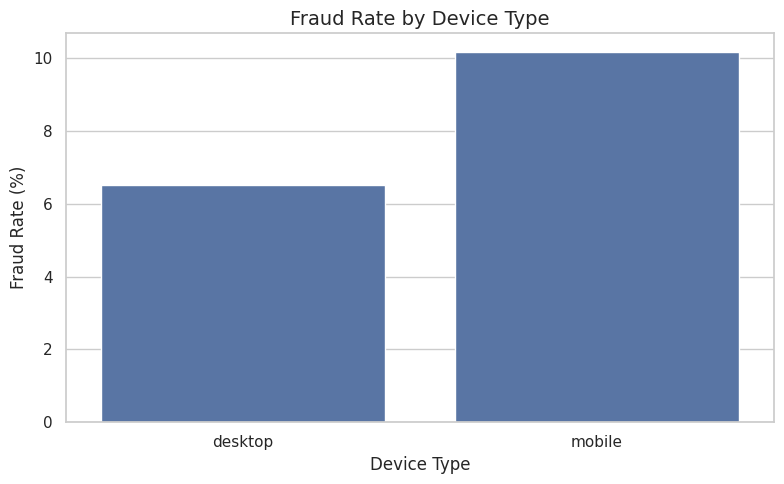

4763

In [19]:
# ============================================================
# EDA 10 — DEVICE TYPE
# ============================================================

print("=" * 60)
print("EDA 10: DEVICE TYPE")
print("=" * 60)

device_summary = (
    train.groupby("DeviceType", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

device_summary["Fraud_Rate"] *= 100

display(
    device_summary
    .sort_values("Fraud_Rate", ascending=False)
    .round(2)
)


plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_summary.reset_index(),
    x="DeviceType",
    y="Fraud_Rate"
)

plt.title(
    "Fraud Rate by Device Type",
    fontsize=14
)

plt.xlabel("Device Type", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

gc.collect()

EDA 11: OPERATING SYSTEM
Operating systems with >=500 transactions:


,Transactions,Fraud_Count,Fraud_Rate
id_30,,,
iOS 11.2.5,1200,146,12.17
iOS 11.2.2,902,106,11.75
Android 7.1.1,630,67,10.63
Android,1079,114,10.57
Android 6.0.1,566,48,8.48
iOS 11.2.0,852,72,8.45
Linux,1136,85,7.48
iOS 11.1.1,700,49,7.00
Windows 8.1,1914,133,6.95


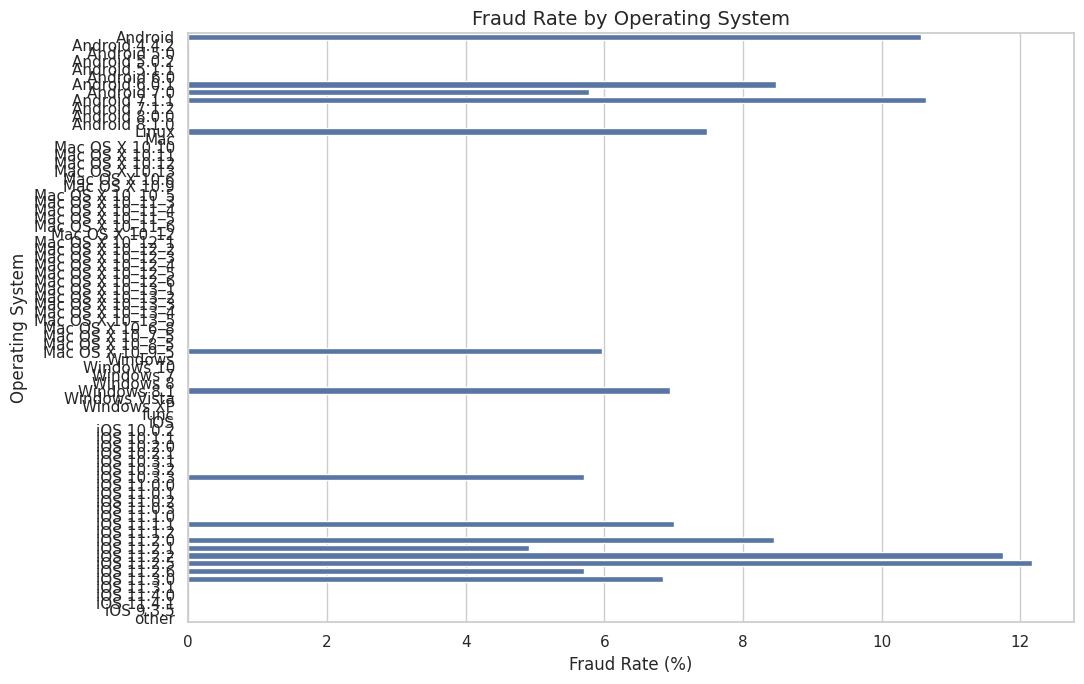

2631

In [20]:
# ============================================================
# EDA 11 — OPERATING SYSTEM (id_30)
# ============================================================

print("=" * 60)
print("EDA 11: OPERATING SYSTEM")
print("=" * 60)

id30_summary = (
    train.groupby("id_30", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

id30_summary["Fraud_Rate"] *= 100

frequent_id30 = (
    id30_summary[
        id30_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
)

print("Operating systems with >=500 transactions:")
display(
    frequent_id30.head(20).round(2)
)


plot_id30 = frequent_id30.head(15).reset_index()

plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_id30,
    x="Fraud_Rate",
    y="id_30"
)

plt.title(
    "Fraud Rate by Operating System",
    fontsize=14
)

plt.xlabel("Fraud Rate (%)", fontsize=12)
plt.ylabel("Operating System", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

del plot_id30
gc.collect()

EDA 12: BROWSER
Browsers with >=500 transactions:


,Transactions,Fraud_Count,Fraud_Rate
id_31,,,
firefox,673,147,21.84
chrome generic,4778,803,16.81
chrome 64.0 for android,3473,552,15.89
chrome 65.0 for android,3336,491,14.72
chrome 61.0 for android,538,72,13.38
chrome 66.0 for android,2349,305,12.98
chrome 63.0 for android,5806,653,11.25
chrome generic for android,1158,127,10.97
mobile safari generic,11474,1146,9.99


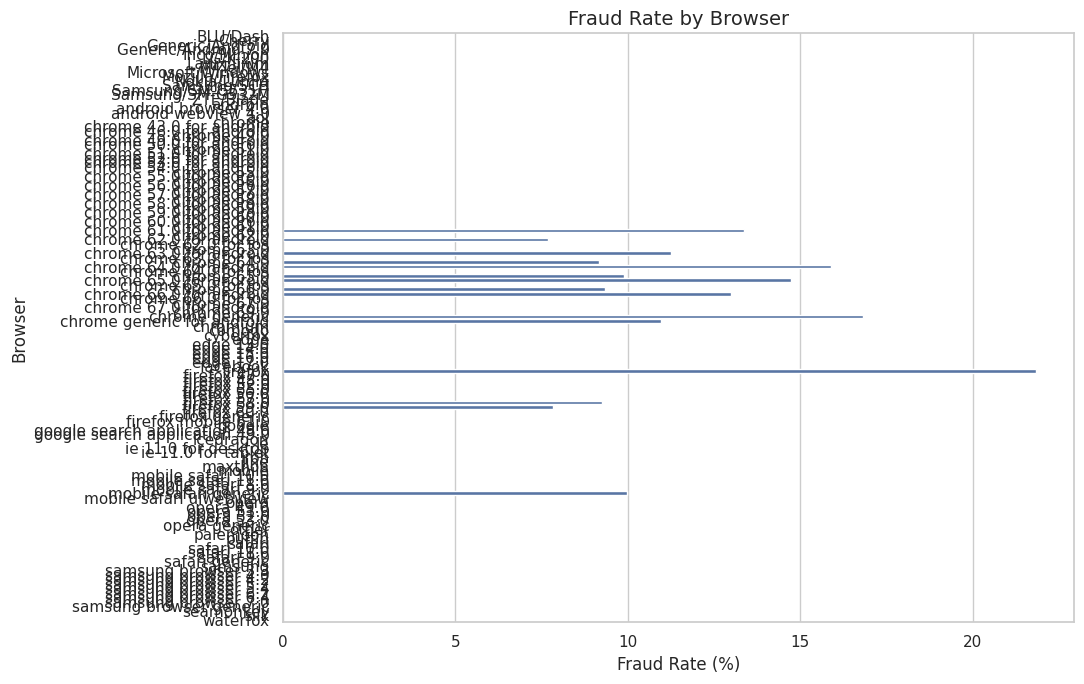

27406

In [21]:
# ============================================================
# EDA 12 — BROWSER (id_31)
# ============================================================

print("=" * 60)
print("EDA 12: BROWSER")
print("=" * 60)

id31_summary = (
    train.groupby("id_31", observed=True)["isFraud"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

id31_summary["Fraud_Rate"] *= 100

frequent_id31 = (
    id31_summary[
        id31_summary["Transactions"] >= 500
    ]
    .sort_values("Fraud_Rate", ascending=False)
)

print("Browsers with >=500 transactions:")
display(
    frequent_id31.head(20).round(2)
)


plot_id31 = frequent_id31.head(15).reset_index()

plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_id31,
    x="Fraud_Rate",
    y="id_31"
)

plt.title(
    "Fraud Rate by Browser",
    fontsize=14
)

plt.xlabel("Fraud Rate (%)", fontsize=12)
plt.ylabel("Browser", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

del plot_id31
gc.collect()

EDA 13: MISSINGNESS BY FRAUD STATUS
Features with largest missingness differences:


,Feature,Missing_Legitimate_Percent,Missing_Fraud_Percent,Difference_pp,Absolute_Difference
16,R_emaildomain,77.88,45.67,-32.21,32.21
395,id_02,77.25,45.69,-31.56,31.56
429,id_36,77.23,45.69,-31.54,31.54
428,id_35,77.23,45.69,-31.54,31.54
430,id_37,77.23,45.69,-31.54,31.54
431,id_38,77.23,45.69,-31.54,31.54
408,id_15,77.23,45.69,-31.54,31.54
421,id_28,77.23,45.71,-31.52,31.52
404,id_11,77.23,45.71,-31.52,31.52
422,id_29,77.23,45.71,-31.52,31.52


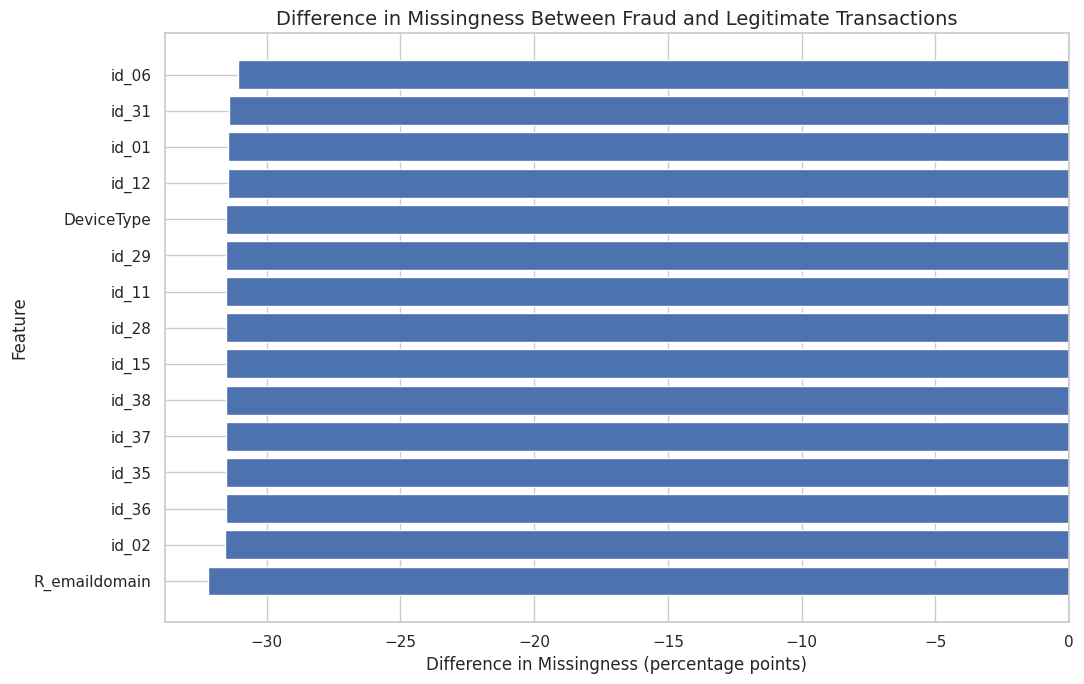

4648

In [22]:
# ============================================================
# EDA 13 — MISSINGNESS BY FRAUD STATUS
# ============================================================

print("=" * 60)
print("EDA 13: MISSINGNESS BY FRAUD STATUS")
print("=" * 60)

missing_by_fraud = []

for col in train.columns:

    legitimate = train.loc[
        train["isFraud"] == 0,
        col
    ].isna().mean() * 100

    fraud = train.loc[
        train["isFraud"] == 1,
        col
    ].isna().mean() * 100

    missing_by_fraud.append([
        col,
        legitimate,
        fraud,
        fraud - legitimate
    ])


missing_comparison = pd.DataFrame(
    missing_by_fraud,
    columns=[
        "Feature",
        "Missing_Legitimate_Percent",
        "Missing_Fraud_Percent",
        "Difference_pp"
    ]
)

# Largest absolute differences
missing_comparison["Absolute_Difference"] = (
    missing_comparison["Difference_pp"].abs()
)

missing_comparison = (
    missing_comparison
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
)

print(
    "Features with largest missingness differences:"
)

display(
    missing_comparison.head(25).round(2)
)


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

missing_plot = (
    missing_comparison
    .head(15)
    .sort_values("Difference_pp")
)

plt.figure(figsize=(11, 7))

plt.barh(
    missing_plot["Feature"],
    missing_plot["Difference_pp"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Difference in Missingness Between Fraud and Legitimate Transactions",
    fontsize=14
)

plt.xlabel(
    "Difference in Missingness (percentage points)",
    fontsize=12
)

plt.ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

del missing_by_fraud
del missing_plot

gc.collect()

EDA 14: IDENTITY DATA AVAILABILITY


,Identity_Status,Transactions,Fraud_Count,Fraud_Rate,Transaction_Percentage
0,Identity Missing,446307,9345,2.09,75.58
1,Identity Available,144233,11318,7.85,24.42


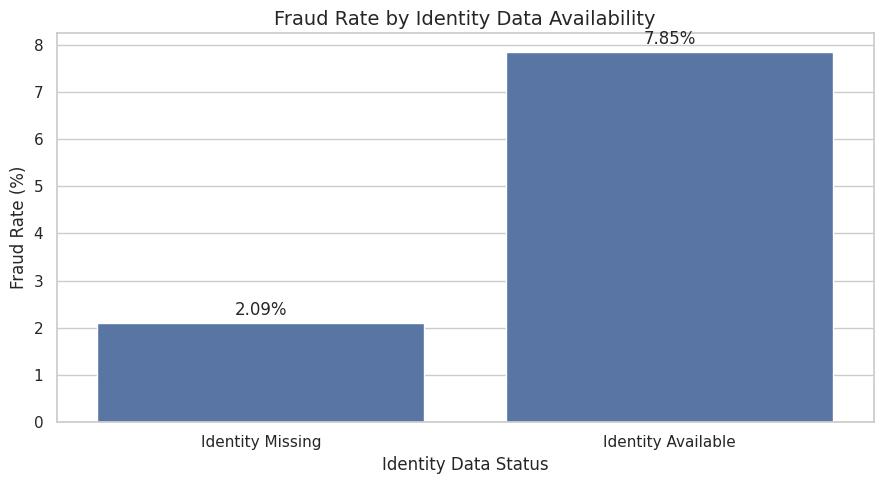

8717

In [23]:
# ============================================================
# EDA 14 — IDENTITY DATA AVAILABILITY
# ============================================================

print("=" * 60)
print("EDA 14: IDENTITY DATA AVAILABILITY")
print("=" * 60)

# id_01 is used as an indicator because it is populated
# when an identity record exists.

has_identity = train["id_01"].notna()

identity_summary = pd.DataFrame({
    "Identity_Status": [
        "Identity Missing",
        "Identity Available"
    ],
    "Transactions": [
        (~has_identity).sum(),
        has_identity.sum()
    ],
    "Fraud_Count": [
        train.loc[~has_identity, "isFraud"].sum(),
        train.loc[has_identity, "isFraud"].sum()
    ]
})

identity_summary["Fraud_Rate"] = (
    identity_summary["Fraud_Count"]
    / identity_summary["Transactions"]
    * 100
)

identity_summary["Transaction_Percentage"] = (
    identity_summary["Transactions"]
    / len(train)
    * 100
)

display(
    identity_summary.round(2)
)


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=identity_summary,
    x="Identity_Status",
    y="Fraud_Rate"
)

plt.title(
    "Fraud Rate by Identity Data Availability",
    fontsize=14
)

plt.xlabel("Identity Data Status", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()
plt.close()

gc.collect()

# Train–Validation Split

The labelled training data is divided into training and validation subsets.

A stratified split is used to preserve the original fraud-to-legitimate class distribution in both subsets.

All feature statistics that could potentially contain information from the target or validation observations will be calculated using the training subset only and subsequently applied to the validation subset.

In [24]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np
import gc

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

# ------------------------------------------------------------
# CREATE INDICES
# ------------------------------------------------------------

indices = np.arange(len(train))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=train["isFraud"],
    random_state=42
)

print(f"Total transactions : {len(train):,}")
print(f"Training rows      : {len(train_idx):,}")
print(f"Validation rows    : {len(valid_idx):,}")


# ------------------------------------------------------------
# TARGET ARRAYS
# ------------------------------------------------------------

y = train["isFraud"].to_numpy()

y_train = y[train_idx]
y_valid = y[valid_idx]


# ------------------------------------------------------------
# TRANSACTION IDs
# ------------------------------------------------------------

train_ids = train.iloc[train_idx]["TransactionID"].to_numpy()
valid_ids = train.iloc[valid_idx]["TransactionID"].to_numpy()


# ------------------------------------------------------------
# CHECK CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nClass distribution:")
print("-" * 60)

print(
    f"Overall fraud rate    : "
    f"{y.mean() * 100:.2f}%"
)

print(
    f"Training fraud rate   : "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Validation fraud rate : "
    f"{y_valid.mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# CLASS COUNTS
# ------------------------------------------------------------

print("\nTraining target:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nValidation target:")
print(
    pd.Series(y_valid)
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# MEMORY
# ------------------------------------------------------------

print("\nMemory:")
print(
    f"Train DataFrame : "
    f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)

gc.collect()

TRAIN / VALIDATION SPLIT
Total transactions : 590,540
Training rows      : 472,432
Validation rows    : 118,108

Class distribution:
------------------------------------------------------------
Overall fraud rate    : 3.50%
Training fraud rate   : 3.50%
Validation fraud rate : 3.50%

Training target:
0    455902
1     16530
Name: count, dtype: int64

Validation target:
0    113975
1      4133
Name: count, dtype: int64

Memory:
Train DataFrame : 0.96 GB


0

# **Feature** **Engineering**

In [25]:
# ============================================================
# FEATURE ENGINEERING — BASIC TRANSACTION FEATURES
# ============================================================

import numpy as np
import pandas as pd
import gc

print("=" * 60)
print("BASIC FEATURE ENGINEERING")
print("=" * 60)

# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------

def add_basic_features(df):
    """
    Create transaction-level features that do not require
    learning statistics from the validation set.
    """

    # --------------------------------------------------------
    # TRANSACTION AMOUNT
    # --------------------------------------------------------

    # Log transformation reduces the effect of very large
    # transaction amounts.
    df["TransactionAmt_log"] = np.log1p(
        df["TransactionAmt"]
    ).astype(np.float32)

    # Amount in cents / decimal component
    df["TransactionAmt_cents"] = (
        (df["TransactionAmt"] % 1) * 100
    ).round().astype(np.float32)


    # --------------------------------------------------------
    # TRANSACTION TIME
    # --------------------------------------------------------

    # TransactionDT is a relative time variable.
    # We do NOT interpret it as a real-world timestamp.

    df["Transaction_hour"] = (
        (df["TransactionDT"] // 3600) % 24
    ).astype(np.int8)

    df["Transaction_day"] = (
        df["TransactionDT"] // (24 * 3600)
    ).astype(np.int16)

    df["Transaction_week"] = (
        df["Transaction_day"] // 7
    ).astype(np.int16)


    # Cyclical representation of hour
    df["Hour_sin"] = np.sin(
        2 * np.pi * df["Transaction_hour"] / 24
    ).astype(np.float32)

    df["Hour_cos"] = np.cos(
        2 * np.pi * df["Transaction_hour"] / 24
    ).astype(np.float32)


    # --------------------------------------------------------
    # MISSINGNESS FEATURES
    # --------------------------------------------------------

    # Overall number of missing fields
    df["Missing_Count"] = (
        df.isna().sum(axis=1)
    ).astype(np.int16)

    df["Missing_Percentage"] = (
        df["Missing_Count"] / df.shape[1] * 100
    ).astype(np.float32)


    # --------------------------------------------------------
    # IDENTITY AVAILABILITY
    # --------------------------------------------------------

    # Identity data exists for only part of the dataset.
    # id_01 is used as an indicator.

    if "id_01" in df.columns:

        df["has_identity"] = (
            df["id_01"].notna()
        ).astype(np.int8)


    # --------------------------------------------------------
    # COMMON COMBINATION FEATURES
    # --------------------------------------------------------

    # Card + address
    if "card1" in df.columns and "addr1" in df.columns:

        df["card1_addr1"] = (
            df["card1"].astype("string")
            + "_"
            + df["addr1"].astype("string")
        ).astype("category")


    # Card + email
    if "card1" in df.columns and "P_emaildomain" in df.columns:

        df["card1_email"] = (
            df["card1"].astype("string")
            + "_"
            + df["P_emaildomain"].astype("string")
        ).astype("category")


    # Product + card type
    if "ProductCD" in df.columns and "card4" in df.columns:

        df["ProductCD_card4"] = (
            df["ProductCD"].astype("string")
            + "_"
            + df["card4"].astype("string")
        ).astype("category")


    # Card type + card category
    if "card4" in df.columns and "card6" in df.columns:

        df["card4_card6"] = (
            df["card4"].astype("string")
            + "_"
            + df["card6"].astype("string")
        ).astype("category")


    return df


# ------------------------------------------------------------
# APPLY TO FULL DATASET
# ------------------------------------------------------------

print("Creating transaction-level features...")

train = add_basic_features(train)

gc.collect()


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print("\nFeature engineering completed.")

print(
    f"New dataset shape: "
    f"{train.shape[0]:,} rows × {train.shape[1]:,} columns"
)

print("\nNew features:")

new_features = [
    "TransactionAmt_log",
    "TransactionAmt_cents",
    "Transaction_hour",
    "Transaction_day",
    "Transaction_week",
    "Hour_sin",
    "Hour_cos",
    "Missing_Count",
    "Missing_Percentage",
    "has_identity",
    "card1_addr1",
    "card1_email",
    "ProductCD_card4",
    "card4_card6"
]

for feature in new_features:
    if feature in train.columns:
        print("✓", feature)

print(
    f"\nDataFrame RAM: "
    f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)

BASIC FEATURE ENGINEERING
Creating transaction-level features...

Feature engineering completed.
New dataset shape: 590,540 rows × 448 columns

New features:
✓ TransactionAmt_log
✓ TransactionAmt_cents
✓ Transaction_hour
✓ Transaction_day
✓ Transaction_week
✓ Hour_sin
✓ Hour_cos
✓ Missing_Count
✓ Missing_Percentage
✓ has_identity
✓ card1_addr1
✓ card1_email
✓ ProductCD_card4
✓ card4_card6

DataFrame RAM: 0.99 GB


In [26]:
# ============================================================
# LEAKAGE-SAFE FREQUENCY FEATURES — CORRECTED
# ============================================================

print("=" * 60)
print("LEAKAGE-SAFE FREQUENCY FEATURES")
print("=" * 60)

import pandas as pd
import numpy as np
import gc


# ------------------------------------------------------------
# FREQUENCY FEATURES
# ------------------------------------------------------------

frequency_columns = [
    "card1",
    "addr1",
    "card1_addr1",
    "P_emaildomain",
    "R_emaildomain",
    "card1_email",
    "ProductCD",
    "DeviceInfo",
    "DeviceType",
    "id_30",
    "id_31"
]

frequency_columns = [
    col for col in frequency_columns
    if col in train.columns
]

print("Frequency features:")

for col in frequency_columns:
    print("✓", col)


# ------------------------------------------------------------
# TRAINING-ONLY DATA
# ------------------------------------------------------------

train_frequency_data = train.iloc[train_idx]


# ------------------------------------------------------------
# CREATE FREQUENCY FEATURES
# ------------------------------------------------------------

for col in frequency_columns:

    print(f"\nProcessing: {col}")

    # Frequency calculated ONLY from training rows
    frequency_map = (
        train_frequency_data[col]
        .value_counts(dropna=False)
    )

    # Convert mapped result to numeric BEFORE fillna.
    # This avoids the pandas Categorical fillna error.
    frequency_values = train[col].map(
        frequency_map
    )

    frequency_values = pd.to_numeric(
        frequency_values,
        errors="coerce"
    )

    train[f"{col}_frequency"] = (
        frequency_values
        .fillna(0)
        .astype(np.float32)
    )

    del frequency_map
    del frequency_values

    gc.collect()


# ------------------------------------------------------------
# CLEANUP
# ------------------------------------------------------------

del train_frequency_data

gc.collect()


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FREQUENCY FEATURES CREATED SUCCESSFULLY")
print("=" * 60)

created_frequency_features = [
    f"{col}_frequency"
    for col in frequency_columns
]

for feature in created_frequency_features:

    print(
        f"{feature:<30} "
        f"min={train[feature].min():.0f}, "
        f"max={train[feature].max():.0f}"
    )


# ------------------------------------------------------------
# DATASET INFORMATION
# ------------------------------------------------------------

print(
    f"\nDataset shape: "
    f"{train.shape[0]:,} rows × {train.shape[1]:,} columns"
)

print(
    f"DataFrame RAM: "
    f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)

LEAKAGE-SAFE FREQUENCY FEATURES
Frequency features:
✓ card1
✓ addr1
✓ card1_addr1
✓ P_emaildomain
✓ R_emaildomain
✓ card1_email
✓ ProductCD
✓ DeviceInfo
✓ DeviceType
✓ id_30
✓ id_31

Processing: card1

Processing: addr1

Processing: card1_addr1

Processing: P_emaildomain

Processing: R_emaildomain

Processing: card1_email

Processing: ProductCD

Processing: DeviceInfo

Processing: DeviceType

Processing: id_30

Processing: id_31

FREQUENCY FEATURES CREATED SUCCESSFULLY
card1_frequency                min=0, max=11984
addr1_frequency                min=0, max=52723
card1_addr1_frequency          min=0, max=52723
P_emaildomain_frequency        min=26, max=182612
R_emaildomain_frequency        min=6, max=362236
card1_email_frequency          min=0, max=75591
ProductCD_frequency            min=9319, max=351450
DeviceInfo_frequency           min=0, max=377225
DeviceType_frequency           min=44762, max=359497
id_30_frequency                min=1, max=410249
id_31_frequency                m

In [27]:
# ============================================================
# LEAKAGE-SAFE TRANSACTION AMOUNT AGGREGATION FEATURES
# ============================================================

print("=" * 60)
print("TRANSACTION AMOUNT AGGREGATION FEATURES")
print("=" * 60)

import pandas as pd
import numpy as np
import gc


# ------------------------------------------------------------
# GROUPS FOR AGGREGATION
# ------------------------------------------------------------

aggregation_groups = [
    "card1",
    "card1_addr1",
    "card1_email",
    "P_emaildomain"
]

aggregation_groups = [
    col for col in aggregation_groups
    if col in train.columns
]

print("Aggregation groups:")

for col in aggregation_groups:
    print("✓", col)


# ------------------------------------------------------------
# TRAINING-ONLY DATA
# ------------------------------------------------------------

train_agg_data = train.iloc[train_idx]


# ------------------------------------------------------------
# CREATE AGGREGATIONS
# ------------------------------------------------------------

for group_col in aggregation_groups:

    print(f"\nProcessing: {group_col}")

    # --------------------------------------------------------
    # Calculate statistics using TRAINING DATA ONLY
    # --------------------------------------------------------

    aggregation_map = (
        train_agg_data
        .groupby(group_col, observed=True)["TransactionAmt"]
        .agg(
            Amount_Mean="mean",
            Amount_Std="std",
            Amount_Min="min",
            Amount_Max="max"
        )
    )


    # --------------------------------------------------------
    # Map statistics back to full dataset
    # --------------------------------------------------------

    for stat in [
        "Amount_Mean",
        "Amount_Std",
        "Amount_Min",
        "Amount_Max"
    ]:

        feature_name = (
            f"{group_col}_{stat}"
        )

        mapped_values = train[group_col].map(
            aggregation_map[stat]
        )

        # Convert categorical mapping to numeric
        mapped_values = pd.to_numeric(
            mapped_values,
            errors="coerce"
        )

        train[feature_name] = (
            mapped_values
            .fillna(0)
            .astype(np.float32)
        )

        del mapped_values

    del aggregation_map

    gc.collect()


# ------------------------------------------------------------
# CLEANUP
# ------------------------------------------------------------

del train_agg_data

gc.collect()


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AGGREGATION FEATURES CREATED")
print("=" * 60)

aggregation_features = []

for group_col in aggregation_groups:

    for stat in [
        "Amount_Mean",
        "Amount_Std",
        "Amount_Min",
        "Amount_Max"
    ]:

        feature_name = (
            f"{group_col}_{stat}"
        )

        aggregation_features.append(
            feature_name
        )

        print("✓", feature_name)


print(
    f"\nDataset shape: "
    f"{train.shape[0]:,} rows × {train.shape[1]:,} columns"
)

print(
    f"DataFrame RAM: "
    f"{train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)

TRANSACTION AMOUNT AGGREGATION FEATURES
Aggregation groups:
✓ card1
✓ card1_addr1
✓ card1_email
✓ P_emaildomain

Processing: card1

Processing: card1_addr1

Processing: card1_email

Processing: P_emaildomain

AGGREGATION FEATURES CREATED
✓ card1_Amount_Mean
✓ card1_Amount_Std
✓ card1_Amount_Min
✓ card1_Amount_Max
✓ card1_addr1_Amount_Mean
✓ card1_addr1_Amount_Std
✓ card1_addr1_Amount_Min
✓ card1_addr1_Amount_Max
✓ card1_email_Amount_Mean
✓ card1_email_Amount_Std
✓ card1_email_Amount_Min
✓ card1_email_Amount_Max
✓ P_emaildomain_Amount_Mean
✓ P_emaildomain_Amount_Std
✓ P_emaildomain_Amount_Min
✓ P_emaildomain_Amount_Max

Dataset shape: 590,540 rows × 475 columns
DataFrame RAM: 1.05 GB


# **Model Data preparation**

In [28]:
# ============================================================
# MODEL DATA PREPARATION
# ============================================================

print("=" * 60)
print("MODEL DATA PREPARATION")
print("=" * 60)

import pandas as pd
import numpy as np
import gc

# ------------------------------------------------------------
# IDENTIFY TARGET
# ------------------------------------------------------------

target_column = "isFraud"

# Columns that should NOT be used as predictors
# TransactionID is an identifier rather than a behavioral
# predictor.
drop_columns = [
    target_column,
    "TransactionID"
]

feature_columns = [
    col for col in train.columns
    if col not in drop_columns
]

print(f"Total model features: {len(feature_columns)}")


# ------------------------------------------------------------
# IDENTIFY CATEGORICAL FEATURES
# ------------------------------------------------------------

categorical_features = train[
    feature_columns
].select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features    : {len(numeric_features)}")


# ------------------------------------------------------------
# CREATE MODEL DATAFRAME
# ------------------------------------------------------------

# We create only the feature columns here.
# This is intentionally separate from the original `train`
# DataFrame.

X = train[feature_columns].copy()

print(
    f"\nInitial model DataFrame RAM: "
    f"{X.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)


# ------------------------------------------------------------
# CONVERT CATEGORICAL FEATURES TO INTEGER CODES
# ------------------------------------------------------------

print("\nEncoding categorical features...")

for col in categorical_features:

    # Convert to category first if necessary
    if not isinstance(X[col].dtype, pd.CategoricalDtype):
        X[col] = X[col].astype("category")

    # Category codes:
    # -1 represents missing/unseen category
    X[col] = X[col].cat.codes.astype(np.int32)


# ------------------------------------------------------------
# REDUCE NUMERIC MEMORY
# ------------------------------------------------------------

for col in numeric_features:

    if X[col].dtype == np.float64:
        X[col] = X[col].astype(np.float32)

    elif X[col].dtype == np.int64:
        X[col] = pd.to_numeric(
            X[col],
            downcast="integer"
        )


gc.collect()


# ------------------------------------------------------------
# CREATE TRAIN / VALIDATION MATRICES
# ------------------------------------------------------------

X_train = X.iloc[train_idx]
X_valid = X.iloc[valid_idx]

print("\nModel matrices:")
print(
    f"X_train: {X_train.shape[0]:,} rows × "
    f"{X_train.shape[1]:,} features"
)

print(
    f"X_valid: {X_valid.shape[0]:,} rows × "
    f"{X_valid.shape[1]:,} features"
)

print(
    f"\nX DataFrame RAM: "
    f"{X.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)


# ------------------------------------------------------------
# TARGET
# ------------------------------------------------------------

y_train = train.iloc[train_idx][target_column].to_numpy(
    dtype=np.int8
)

y_valid = train.iloc[valid_idx][target_column].to_numpy(
    dtype=np.int8
)

print("\nTargets:")
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL PREPARATION COMPLETE")
print("=" * 60)

print("Training fraud cases   :", y_train.sum())
print("Validation fraud cases :", y_valid.sum())

print(
    "Training fraud rate     :",
    f"{y_train.mean() * 100:.2f}%"
)

print(
    "Validation fraud rate   :",
    f"{y_valid.mean() * 100:.2f}%"
)

print(
    "\nMissing values in X:",
    X.isna().sum().sum()
)

gc.collect()

MODEL DATA PREPARATION
Total model features: 473
Categorical features: 35
Numeric features    : 438

Initial model DataFrame RAM: 1.04 GB

Encoding categorical features...

Model matrices:
X_train: 472,432 rows × 473 features
X_valid: 118,108 rows × 473 features

X DataFrame RAM: 1.03 GB

Targets:
y_train: (472432,)
y_valid: (118108,)

MODEL PREPARATION COMPLETE
Training fraud cases   : 16530
Validation fraud cases : 4133
Training fraud rate     : 3.50%
Validation fraud rate   : 3.50%

Missing values in X: 104178894


0

# **XGBoost Model**

In [29]:
# ============================================================
# XGBOOST BASELINE MODEL
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import pandas as pd
import gc
import time

print("=" * 60)
print("XGBOOST BASELINE")
print("=" * 60)


# ------------------------------------------------------------
# CLASS IMBALANCE
# ------------------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print(f"Legitimate transactions : {negative_count:,}")
print(f"Fraud transactions      : {positive_count:,}")
print(
    f"Scale positive weight   : "
    f"{scale_pos_weight:.2f}"
)


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,
    gamma=0,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    device="cuda",

    random_state=42,
    n_jobs=4
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

print("\nTraining XGBoost...")

start_time = time.time()

xgb_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_valid, y_valid)
    ],

    verbose=False
)

training_time = time.time() - start_time

print(
    f"Training completed in "
    f"{training_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

print("\nGenerating validation predictions...")

xgb_valid_proba = xgb_model.predict_proba(
    X_valid
)[:, 1]


# ------------------------------------------------------------
# DEFAULT THRESHOLD = 0.50
# ------------------------------------------------------------

xgb_valid_pred = (
    xgb_valid_proba >= 0.50
).astype(np.int8)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_valid,
    xgb_valid_proba
)

pr_auc = average_precision_score(
    y_valid,
    xgb_valid_proba
)

precision = precision_score(
    y_valid,
    xgb_valid_pred,
    zero_division=0
)

recall = recall_score(
    y_valid,
    xgb_valid_pred,
    zero_division=0
)

f1 = f1_score(
    y_valid,
    xgb_valid_pred,
    zero_division=0
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("XGBOOST VALIDATION RESULTS")
print("=" * 60)

print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_valid,
    xgb_valid_pred
)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        xgb_valid_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

xgb_results = {
    "Model": "XGBoost",
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
}

print("\nResult dictionary:")
print(xgb_results)

gc.collect()

XGBOOST BASELINE
Legitimate transactions : 455,902
Fraud transactions      : 16,530
Scale positive weight   : 27.58

Training XGBoost...
Training completed in 0.86 minutes

Generating validation predictions...

XGBOOST VALIDATION RESULTS
ROC-AUC   : 0.9574
PR-AUC    : 0.7239
Precision : 0.3182
Recall    : 0.8364
F1 Score  : 0.4610

Confusion Matrix:
[[106568   7407]
 [   676   3457]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.94      0.96    113975
       Fraud       0.32      0.84      0.46      4133

    accuracy                           0.93    118108
   macro avg       0.66      0.89      0.71    118108
weighted avg       0.97      0.93      0.95    118108


Result dictionary:
{'Model': 'XGBoost', 'ROC_AUC': np.float64(0.9574032417511471), 'PR_AUC': np.float64(0.7239147977527913), 'Precision': 0.3182069219440353, 'Recall': 0.8364384224534237, 'F1': 0.46102553844102157}


53

In [30]:
# ============================================================
# CATBOOST BASELINE MODEL
# ============================================================

from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import pandas as pd
import gc
import time

print("=" * 60)
print("CATBOOST BASELINE")
print("=" * 60)


# ------------------------------------------------------------
# CATBOOST DATA
# ------------------------------------------------------------

# Use the already prepared X matrix.
# Convert categorical feature indices to integers.
#
# CatBoost needs to know which columns are categorical.

cat_feature_indices = [
    X.columns.get_loc(col)
    for col in categorical_features
]

print(
    f"Categorical features supplied to CatBoost: "
    f"{len(cat_feature_indices)}"
)


# ------------------------------------------------------------
# CLASS IMBALANCE
# ------------------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

catboost_class_weight = (
    negative_count / positive_count
)

print(
    f"Class weight for fraud: "
    f"{catboost_class_weight:.2f}"
)


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

cat_model = CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.05,

    loss_function="Logloss",
    eval_metric="PRAUC",

    class_weights=[
        1.0,
        catboost_class_weight
    ],

    task_type="GPU",
    devices="0",

    random_seed=42,

    verbose=False,

    allow_writing_files=False
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

print("\nTraining CatBoost...")

start_time = time.time()

cat_model.fit(
    X_train,
    y_train,

    cat_features=cat_feature_indices,

    eval_set=(X_valid, y_valid),

    early_stopping_rounds=50,

    verbose=False
)

training_time = time.time() - start_time

print(
    f"Training completed in "
    f"{training_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# BEST ITERATION
# ------------------------------------------------------------

print(
    "Best iteration:",
    cat_model.get_best_iteration()
)


# ------------------------------------------------------------
# VALIDATION PREDICTIONS
# ------------------------------------------------------------

print("\nGenerating validation predictions...")

cat_valid_proba = cat_model.predict_proba(
    X_valid
)[:, 1]


# ------------------------------------------------------------
# DEFAULT THRESHOLD
# ------------------------------------------------------------

cat_valid_pred = (
    cat_valid_proba >= 0.50
).astype(np.int8)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

cat_roc_auc = roc_auc_score(
    y_valid,
    cat_valid_proba
)

cat_pr_auc = average_precision_score(
    y_valid,
    cat_valid_proba
)

cat_precision = precision_score(
    y_valid,
    cat_valid_pred,
    zero_division=0
)

cat_recall = recall_score(
    y_valid,
    cat_valid_pred,
    zero_division=0
)

cat_f1 = f1_score(
    y_valid,
    cat_valid_pred,
    zero_division=0
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CATBOOST VALIDATION RESULTS")
print("=" * 60)

print(f"ROC-AUC   : {cat_roc_auc:.4f}")
print(f"PR-AUC    : {cat_pr_auc:.4f}")
print(f"Precision : {cat_precision:.4f}")
print(f"Recall    : {cat_recall:.4f}")
print(f"F1 Score  : {cat_f1:.4f}")


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cat_cm = confusion_matrix(
    y_valid,
    cat_valid_pred
)

print("\nConfusion Matrix:")
print(cat_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_valid,
        cat_valid_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

cat_results = {
    "Model": "CatBoost",
    "ROC_AUC": cat_roc_auc,
    "PR_AUC": cat_pr_auc,
    "Precision": cat_precision,
    "Recall": cat_recall,
    "F1": cat_f1
}

print("\nResult dictionary:")
print(cat_results)

gc.collect()

CATBOOST BASELINE
Categorical features supplied to CatBoost: 35
Class weight for fraud: 27.58

Training CatBoost...


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Training completed in 2.35 minutes
Best iteration: 499

Generating validation predictions...

CATBOOST VALIDATION RESULTS
ROC-AUC   : 0.9713
PR-AUC    : 0.8066
Precision : 0.3609
Recall    : 0.8889
F1 Score  : 0.5134

Confusion Matrix:
[[107469   6506]
 [   459   3674]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.94      0.97    113975
       Fraud       0.36      0.89      0.51      4133

    accuracy                           0.94    118108
   macro avg       0.68      0.92      0.74    118108
weighted avg       0.97      0.94      0.95    118108


Result dictionary:
{'Model': 'CatBoost', 'ROC_AUC': np.float64(0.9712957584317921), 'PR_AUC': np.float64(0.8065594984625104), 'Precision': 0.3609037328094303, 'Recall': 0.8889426566658601, 'F1': 0.5133794452595543}


0

In [31]:
# ============================================================
# SUPERVISED ENSEMBLE: XGBOOST + CATBOOST
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("XGBOOST + CATBOOST ENSEMBLE")
print("=" * 60)

# ------------------------------------------------------------
# Equal-weight probability ensemble
# ------------------------------------------------------------

ensemble_valid_proba = (
    xgb_valid_proba + cat_valid_proba
) / 2

# ------------------------------------------------------------
# Default threshold
# ------------------------------------------------------------

ensemble_valid_pred = (
    ensemble_valid_proba >= 0.50
).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

ensemble_roc_auc = roc_auc_score(
    y_valid,
    ensemble_valid_proba
)

ensemble_pr_auc = average_precision_score(
    y_valid,
    ensemble_valid_proba
)

ensemble_precision = precision_score(
    y_valid,
    ensemble_valid_pred,
    zero_division=0
)

ensemble_recall = recall_score(
    y_valid,
    ensemble_valid_pred,
    zero_division=0
)

ensemble_f1 = f1_score(
    y_valid,
    ensemble_valid_pred,
    zero_division=0
)

ensemble_cm = confusion_matrix(
    y_valid,
    ensemble_valid_pred
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\nEnsemble Validation Results")
print("-" * 60)

print(f"ROC-AUC   : {ensemble_roc_auc:.4f}")
print(f"PR-AUC    : {ensemble_pr_auc:.4f}")
print(f"Precision : {ensemble_precision:.4f}")
print(f"Recall    : {ensemble_recall:.4f}")
print(f"F1 Score  : {ensemble_f1:.4f}")

print("\nConfusion Matrix:")
print(ensemble_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        ensemble_valid_pred,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Probability distribution
# ------------------------------------------------------------

print("\nProbability Statistics")
print("-" * 60)

print(f"Minimum : {ensemble_valid_proba.min():.6f}")
print(f"Maximum : {ensemble_valid_proba.max():.6f}")
print(f"Mean    : {ensemble_valid_proba.mean():.6f}")
print(f"Median  : {np.median(ensemble_valid_proba):.6f}")

# ------------------------------------------------------------
# Threshold analysis
# ------------------------------------------------------------

print("\nThreshold Analysis")
print("-" * 60)

threshold_results = []

for threshold in [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]:

    pred = (
        ensemble_valid_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_valid,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        pred,
        zero_division=0
    )

    flagged = pred.sum()

    fraud_captured = (
        ((pred == 1) & (y_valid == 1)).sum()
    )

    threshold_results.append({
        "Threshold": threshold,
        "Flagged": flagged,
        "Flagged_%": flagged / len(y_valid) * 100,
        "Fraud_Captured": fraud_captured,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Flagged_%": "{:.2f}%",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Save ensemble results
# ------------------------------------------------------------

ensemble_results = {
    "Model": "XGBoost + CatBoost Ensemble",
    "ROC-AUC": ensemble_roc_auc,
    "PR-AUC": ensemble_pr_auc,
    "Precision": ensemble_precision,
    "Recall": ensemble_recall,
    "F1": ensemble_f1
}

print("\nEnsemble evaluation complete.")

XGBOOST + CATBOOST ENSEMBLE

Ensemble Validation Results
------------------------------------------------------------
ROC-AUC   : 0.9694
PR-AUC    : 0.7824
Precision : 0.3702
Recall    : 0.8795
F1 Score  : 0.5210

Confusion Matrix:
[[107790   6185]
 [   498   3635]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9954    0.9457    0.9699    113975
           1     0.3702    0.8795    0.5210      4133

    accuracy                         0.9434    118108
   macro avg     0.6828    0.9126    0.7455    118108
weighted avg     0.9735    0.9434    0.9542    118108


Probability Statistics
------------------------------------------------------------
Minimum : 0.000586
Maximum : 0.999848
Mean    : 0.180233
Median  : 0.103306

Threshold Analysis
------------------------------------------------------------


,Threshold,Flagged,Flagged_%,Fraud_Captured,Precision,Recall,F1
0,0.10,60424,51.16%,4092,0.0677,0.9901,0.1268
1,0.15,44311,37.52%,4048,0.0914,0.9794,0.1671
2,0.20,33438,28.31%,3994,0.1194,0.9664,0.2126
3,0.25,26234,22.21%,3950,0.1506,0.9557,0.2602
4,0.30,21102,17.87%,3887,0.1842,0.9405,0.3081
5,0.35,17163,14.53%,3830,0.2232,0.9267,0.3597
6,0.40,14105,11.94%,3771,0.2674,0.9124,0.4135
7,0.45,11721,9.92%,3690,0.3148,0.8928,0.4655
8,0.50,9820,8.31%,3635,0.3702,0.8795,0.5210



Ensemble evaluation complete.


In [32]:
# ============================================================
# ISOLATION FOREST - UNSUPERVISED ANOMALY DETECTION
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer

print("=" * 60)
print("ISOLATION FOREST")
print("=" * 60)

# ------------------------------------------------------------
# Select interpretable behavioral features
# ------------------------------------------------------------

iforest_features = [
    "TransactionAmt",
    "TransactionAmt_log",
    "TransactionAmt_cents",
    "Transaction_hour",
    "Transaction_day",
    "Transaction_week",
    "Missing_Count",
    "Missing_Percentage",

    "card1_frequency",
    "addr1_frequency",
    "card1_addr1_frequency",
    "P_emaildomain_frequency",
    "R_emaildomain_frequency",
    "card1_email_frequency",

    "card1_Amount_Mean",
    "card1_Amount_Std",
    "card1_Amount_Min",
    "card1_Amount_Max",

    "card1_addr1_Amount_Mean",
    "card1_addr1_Amount_Std",
    "card1_addr1_Amount_Min",
    "card1_addr1_Amount_Max",

    "card1_email_Amount_Mean",
    "card1_email_Amount_Std",
    "card1_email_Amount_Min",
    "card1_email_Amount_Max"
]

print(f"Number of features: {len(iforest_features)}")

# ------------------------------------------------------------
# Extract train / validation data
# ------------------------------------------------------------

X_iforest_train = train.iloc[
    train_idx
][iforest_features].copy()

X_iforest_valid = train.iloc[
    valid_idx
][iforest_features].copy()

# ------------------------------------------------------------
# Convert to float32
# ------------------------------------------------------------

X_iforest_train = X_iforest_train.astype("float32")
X_iforest_valid = X_iforest_valid.astype("float32")

# ------------------------------------------------------------
# Impute missing values using TRAINING data only
# ------------------------------------------------------------

imputer = SimpleImputer(
    strategy="median"
)

X_iforest_train = imputer.fit_transform(
    X_iforest_train
).astype("float32")

X_iforest_valid = imputer.transform(
    X_iforest_valid
).astype("float32")

print(
    f"Training matrix : {X_iforest_train.shape}"
)

print(
    f"Validation matrix: {X_iforest_valid.shape}"
)

# ------------------------------------------------------------
# Train Isolation Forest
# ------------------------------------------------------------

iforest = IsolationForest(
    n_estimators=300,
    max_samples=100000,
    contamination="auto",
    random_state=42,
    n_jobs=4
)

print("\nTraining Isolation Forest...")

iforest.fit(
    X_iforest_train
)

print("Isolation Forest training complete.")

# ------------------------------------------------------------
# Generate anomaly scores
# ------------------------------------------------------------
# decision_function:
# larger = more normal
# smaller = more anomalous
#
# We reverse the sign so that:
# larger = more anomalous

iforest_valid_score = -iforest.decision_function(
    X_iforest_valid
)

# ------------------------------------------------------------
# Evaluate anomaly ranking against fraud labels
# ------------------------------------------------------------

iforest_roc_auc = roc_auc_score(
    y_valid,
    iforest_valid_score
)

iforest_pr_auc = average_precision_score(
    y_valid,
    iforest_valid_score
)

print("\n" + "=" * 60)
print("ISOLATION FOREST RESULTS")
print("=" * 60)

print(
    f"ROC-AUC : {iforest_roc_auc:.4f}"
)

print(
    f"PR-AUC  : {iforest_pr_auc:.4f}"
)

print("\nAnomaly score statistics:")
print(
    f"Minimum : {iforest_valid_score.min():.6f}"
)
print(
    f"Maximum : {iforest_valid_score.max():.6f}"
)
print(
    f"Mean    : {iforest_valid_score.mean():.6f}"
)
print(
    f"Median  : {np.median(iforest_valid_score):.6f}"
)

# ------------------------------------------------------------
# Save model/results
# ------------------------------------------------------------

iforest_results = {
    "Model": "Isolation Forest",
    "ROC-AUC": iforest_roc_auc,
    "PR-AUC": iforest_pr_auc
}

print("\nIsolation Forest evaluation complete.")

ISOLATION FOREST
Number of features: 26
Training matrix : (472432, 26)
Validation matrix: (118108, 26)

Training Isolation Forest...
Isolation Forest training complete.

ISOLATION FOREST RESULTS
ROC-AUC : 0.6507
PR-AUC  : 0.0550

Anomaly score statistics:
Minimum : -0.147762
Maximum : 0.224726
Mean    : -0.099188
Median  : -0.105511

Isolation Forest evaluation complete.


In [33]:
# ============================================================
# SUPERVISED RISK × ANOMALY ANALYSIS
# ============================================================

print("=" * 60)
print("SUPERVISED RISK × ANOMALY ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Create working dataframe
# ------------------------------------------------------------

risk_anomaly_df = pd.DataFrame({
    "supervised_risk": ensemble_valid_proba,
    "anomaly_score": iforest_valid_score,
    "isFraud": y_valid
})

# ------------------------------------------------------------
# Use MEDIANS to divide scores into high / low groups
# ------------------------------------------------------------

risk_threshold = risk_anomaly_df["supervised_risk"].median()
anomaly_threshold = risk_anomaly_df["anomaly_score"].median()

print(f"Supervised-risk median : {risk_threshold:.6f}")
print(f"Anomaly-score median   : {anomaly_threshold:.6f}")

risk_anomaly_df["supervised_group"] = np.where(
    risk_anomaly_df["supervised_risk"] >= risk_threshold,
    "High supervised risk",
    "Low supervised risk"
)

risk_anomaly_df["anomaly_group"] = np.where(
    risk_anomaly_df["anomaly_score"] >= anomaly_threshold,
    "High anomaly",
    "Low anomaly"
)

# ------------------------------------------------------------
# Create four quadrants
# ------------------------------------------------------------

def create_quadrant(row):

    if (
        row["supervised_group"] == "Low supervised risk"
        and row["anomaly_group"] == "Low anomaly"
    ):
        return "Low Risk + Low Anomaly"

    elif (
        row["supervised_group"] == "High supervised risk"
        and row["anomaly_group"] == "Low anomaly"
    ):
        return "High Risk + Low Anomaly"

    elif (
        row["supervised_group"] == "Low supervised risk"
        and row["anomaly_group"] == "High anomaly"
    ):
        return "Low Risk + High Anomaly"

    else:
        return "High Risk + High Anomaly"


risk_anomaly_df["quadrant"] = (
    risk_anomaly_df.apply(
        create_quadrant,
        axis=1
    )
)

# ------------------------------------------------------------
# Calculate quadrant statistics
# ------------------------------------------------------------

quadrant_summary = (
    risk_anomaly_df
    .groupby("quadrant")
    .agg(
        Transactions=("isFraud", "size"),
        Fraud_Count=("isFraud", "sum"),
        Fraud_Rate=("isFraud", "mean")
    )
    .reset_index()
)

quadrant_summary["Transaction_%"] = (
    quadrant_summary["Transactions"]
    / len(risk_anomaly_df)
    * 100
)

quadrant_summary["Fraud_Rate_%"] = (
    quadrant_summary["Fraud_Rate"]
    * 100
)

# ------------------------------------------------------------
# Order quadrants logically
# ------------------------------------------------------------

quadrant_order = [
    "Low Risk + Low Anomaly",
    "High Risk + Low Anomaly",
    "Low Risk + High Anomaly",
    "High Risk + High Anomaly"
]

quadrant_summary["Order"] = (
    quadrant_summary["quadrant"]
    .map({
        name: i
        for i, name in enumerate(quadrant_order)
    })
)

quadrant_summary = (
    quadrant_summary
    .sort_values("Order")
    .drop(columns="Order")
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nQuadrant Analysis:")
print("-" * 60)

display(
    quadrant_summary[
        [
            "quadrant",
            "Transactions",
            "Transaction_%",
            "Fraud_Count",
            "Fraud_Rate_%"
        ]
    ].style.format({
        "Transaction_%": "{:.2f}%",
        "Fraud_Rate_%": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# Compare each group with overall fraud rate
# ------------------------------------------------------------

overall_fraud_rate = y_valid.mean() * 100

print(
    f"\nOverall validation fraud rate: "
    f"{overall_fraud_rate:.2f}%"
)

print("\nFraud rate by quadrant:")
print("-" * 60)

for _, row in quadrant_summary.iterrows():

    lift = (
        row["Fraud_Rate_%"]
        / overall_fraud_rate
    )

    print(
        f"{row['quadrant']:<30} "
        f"Fraud Rate: {row['Fraud_Rate_%']:>6.2f}% | "
        f"Lift: {lift:>5.2f}x"
    )

print("\nAnalysis complete.")

SUPERVISED RISK × ANOMALY ANALYSIS
Supervised-risk median : 0.103306
Anomaly-score median   : -0.105511

Quadrant Analysis:
------------------------------------------------------------


,quadrant,Transactions,Transaction_%,Fraud_Count,Fraud_Rate_%
3,Low Risk + Low Anomaly,34387,29.11%,19,0.06%
1,High Risk + Low Anomaly,24667,20.89%,1000,4.05%
2,Low Risk + High Anomaly,24667,20.89%,25,0.10%
0,High Risk + High Anomaly,34387,29.11%,3089,8.98%



Overall validation fraud rate: 3.50%

Fraud rate by quadrant:
------------------------------------------------------------
Low Risk + Low Anomaly         Fraud Rate:   0.06% | Lift:  0.02x
High Risk + Low Anomaly        Fraud Rate:   4.05% | Lift:  1.16x
Low Risk + High Anomaly        Fraud Rate:   0.10% | Lift:  0.03x
High Risk + High Anomaly       Fraud Rate:   8.98% | Lift:  2.57x

Analysis complete.


# **Error Analysis**

In [34]:
# ============================================================
# ERROR ANALYSIS - FALSE POSITIVES & FALSE NEGATIVES
# ============================================================

print("=" * 60)
print("ENSEMBLE ERROR ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Create validation error dataframe
# ------------------------------------------------------------

error_df = train.iloc[valid_idx].copy()

error_df["predicted_probability"] = ensemble_valid_proba
error_df["predicted_class"] = ensemble_valid_pred

# ------------------------------------------------------------
# Assign prediction outcome
# ------------------------------------------------------------

error_df["prediction_type"] = np.select(
    [
        (error_df["isFraud"] == 1) &
        (error_df["predicted_class"] == 1),

        (error_df["isFraud"] == 0) &
        (error_df["predicted_class"] == 1),

        (error_df["isFraud"] == 1) &
        (error_df["predicted_class"] == 0),

        (error_df["isFraud"] == 0) &
        (error_df["predicted_class"] == 0)
    ],
    [
        "True Positive",
        "False Positive",
        "False Negative",
        "True Negative"
    ],
    default="Unknown"
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nPrediction outcome counts:")
print(
    error_df["prediction_type"]
    .value_counts()
)

# ------------------------------------------------------------
# Compare important numerical variables
# ------------------------------------------------------------

numerical_error_features = [
    "TransactionAmt",
    "TransactionAmt_log",
    "Transaction_hour",
    "Transaction_day",
    "Missing_Count",
    "Missing_Percentage",
    "card1_frequency",
    "addr1_frequency",
    "card1_addr1_frequency",
    "P_emaildomain_frequency",
    "R_emaildomain_frequency",
    "card1_email_frequency",
    "card1_Amount_Mean",
    "card1_Amount_Std",
    "card1_Amount_Min",
    "card1_Amount_Max"
]

# Keep only columns that exist
numerical_error_features = [
    col for col in numerical_error_features
    if col in error_df.columns
]

# ------------------------------------------------------------
# Calculate group statistics
# ------------------------------------------------------------

error_summary = (
    error_df
    .groupby("prediction_type")[numerical_error_features]
    .agg(["mean", "median"])
)

print("\nNumerical feature comparison:")
display(error_summary)

# ------------------------------------------------------------
# Error rates by selected categorical features
# ------------------------------------------------------------

categorical_error_features = [
    "ProductCD",
    "card4",
    "card6",
    "DeviceType",
    "P_emaildomain"
]

for feature in categorical_error_features:

    if feature not in error_df.columns:
        continue

    print("\n" + "=" * 60)
    print(f"ERROR ANALYSIS: {feature}")
    print("=" * 60)

    temp = (
        error_df
        .groupby(
            ["prediction_type", feature],
            dropna=False
        )
        .size()
        .reset_index(name="Count")
    )

    display(
        temp.sort_values(
            ["prediction_type", "Count"],
            ascending=[True, False]
        ).head(30)
    )

print("\nError analysis complete.")

ENSEMBLE ERROR ANALYSIS

Prediction outcome counts:
prediction_type
True Negative     107790
False Positive      6185
True Positive       3635
False Negative       498
Name: count, dtype: int64

Numerical feature comparison:


TransactionAmt            TransactionAmt_log            \
                          mean     median               mean    median   
prediction_type                                                          
False Negative      178.653473  88.105499           4.537094  4.489820   
False Positive      172.790344  87.000000           4.479601  4.477337   
True Negative       131.912842  67.949997           4.378587  4.233382   
True Positive       151.352203  74.739998           4.370392  4.327306   

                Transaction_hour        Transaction_day        Missing_Count  \
                            mean median            mean median          mean   
prediction_type                                                                
False Negative         14.347390   17.0       86.487952   87.0    200.927711   
False Positive         13.843007   17.0       89.232175   89.0    171.576071   
True Negative          13.895269   16.0       84.278217   83.0    198.634762   
True Positive          13.028336   16.0       88.564787   87.0    155.929023   

                       Missing_Percentage            card1_frequency          \
                median               mean     median            mean  median   
prediction_type                                                                
False Negative   213.0          45.458755  48.190044     2654.481934  1345.5   
False Positive   208.0          38.818115  47.058823     2149.260498  1069.0   
True Negative    212.0          44.939991  47.963802     2009.473389   702.0   
True Positive    132.0          35.278061  29.864254     1779.367798   743.0   

                addr1_frequency          card1_addr1_frequency         \
                           mean   median                  mean median   
prediction_type                                                         
False Negative     23952.050781  20965.0           7431.873535  271.0   
False Positive     31896.841797  34170.0          20776.757812  656.0   
True Negative      20893.906250  16687.0           4825.310059  106.0   
True Positive      31339.546875  33618.0          21588.601562  497.0   

                P_emaildomain_frequency          R_emaildomain_frequency  \
                                   mean   median                    mean   
prediction_type                                                            
False Negative            108995.507812  80629.0            283580.93750   
False Positive            117094.078125  80629.0            200969.62500   
True Negative             101370.734375  80629.0            294123.21875   
True Positive             113908.632812  80629.0            168837.00000   

                          card1_email_frequency        card1_Amount_Mean  \
                   median                  mean median              mean   
prediction_type                                                            
False Negative   362236.0          15395.389648  491.5        134.079727   
False Positive   362236.0           9867.397461  349.0        125.379974   
True Negative    362236.0          12755.530273  218.0        135.056885   
True Positive     45780.0          10192.339844  254.0        123.106606   

                            card1_Amount_Std             card1_Amount_Min  \
                     median             mean      median             mean   
prediction_type                                                             
False Negative   121.792282       195.648026  182.996628        10.332007   
False Positive   116.018394       176.487091  157.349747         9.395640   
True Negative    120.447037       186.079285  172.724976        15.015711   
True Positive    108.241478       164.322556  116.348549        12.164129   

                       card1_Amount_Max               
                median             mean       median  
prediction_type                                       
False Negative    6.95      2625.742432  2559.399902  
False Positive    5.00      2204.3906


ERROR ANALYSIS: ProductCD


,prediction_type,ProductCD,Count
4,False Negative,W,376
0,False Negative,C,70
1,False Negative,H,22
2,False Negative,R,22
3,False Negative,S,8
9,False Positive,W,3006
5,False Positive,C,2508
6,False Positive,H,324
7,False Positive,R,252
8,False Positive,S,95



ERROR ANALYSIS: card4


...


ERROR ANALYSIS: DeviceType


,prediction_type,DeviceType,Count
2,False Negative,NaN,390
0,False Negative,desktop,68
1,False Negative,mobile,40
5,False Positive,NaN,3350
3,False Positive,desktop,1484
4,False Positive,mobile,1351
8,True Negative,NaN,85018
6,True Negative,desktop,14392
7,True Negative,mobile,8380
11,True Positive,NaN,1475



ERROR ANALYSIS: P_emaildomain


,prediction_type,P_emaildomain,Count
6,False Negative,gmail.com,213
22,False Negative,NaN,97
19,False Negative,yahoo.com,66
7,False Negative,hotmail.com,39
0,False Negative,anonymous.com,25
1,False Negative,aol.com,21
8,False Negative,icloud.com,5
15,False Negative,outlook.com,5
2,False Negative,bellsouth.net,4
5,False Negative,cox.net,3



Error analysis complete.


# **SHAP Analysis**

SHAP EXPLAINABILITY - CATBOOST
SHAP sample size: 2,000

Creating SHAP explainer...
Calculating SHAP values...
SHAP matrix shape: (2000, 473)

Top 30 features by mean absolute SHAP value:


,Feature,Mean_Absolute_SHAP
0,card1_addr1,0.624567
1,C1,0.380659
2,card1_email,0.355959
3,D2,0.245984
4,C13,0.219092
5,C14,0.178080
6,card1_addr1_frequency,0.171215
7,TransactionAmt,0.141032
8,C11,0.134323
9,M5,0.130142


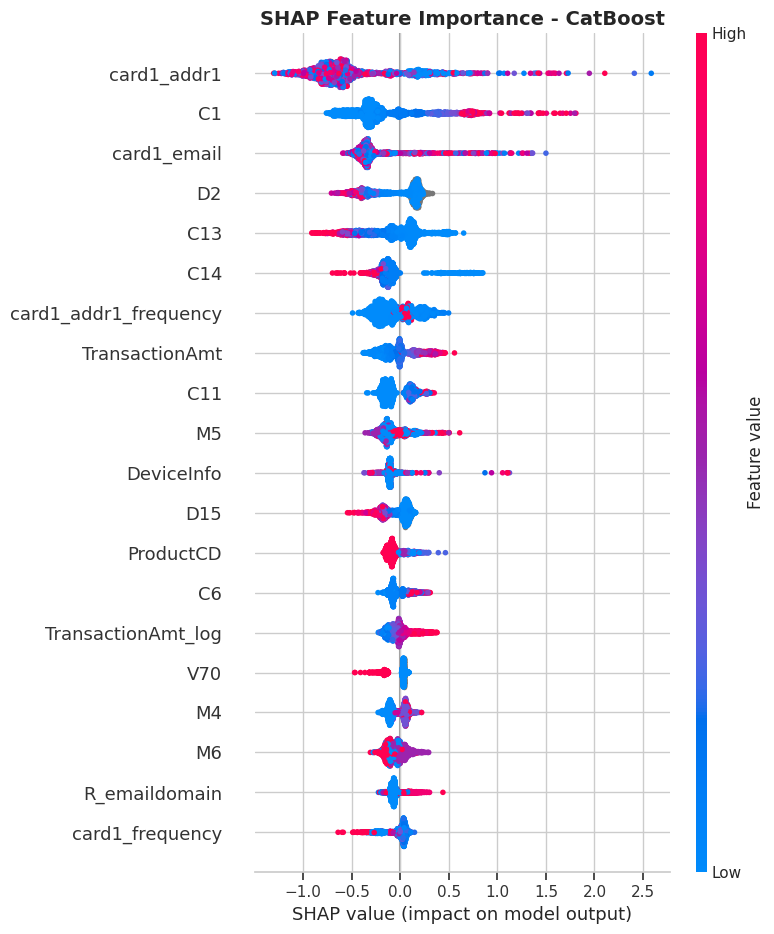


SHAP analysis complete.


In [35]:
# ============================================================
# SHAP EXPLAINABILITY - CATBOOST
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("SHAP EXPLAINABILITY - CATBOOST")
print("=" * 60)

# ------------------------------------------------------------
# Take a manageable validation sample
# ------------------------------------------------------------

shap_sample_size = 2000

rng = np.random.RandomState(42)

shap_indices = rng.choice(
    len(X_valid),
    size=shap_sample_size,
    replace=False
)

X_shap = X_valid.iloc[shap_indices].copy()

print(
    f"SHAP sample size: {len(X_shap):,}"
)

# ------------------------------------------------------------
# Create SHAP explainer
# ------------------------------------------------------------

print("\nCreating SHAP explainer...")

explainer = shap.TreeExplainer(
    cat_model
)

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

print("Calculating SHAP values...")

shap_values = explainer.shap_values(
    X_shap
)

# ------------------------------------------------------------
# Handle binary classification output
# ------------------------------------------------------------

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print(
    f"SHAP matrix shape: {shap_values_plot.shape}"
)

# ------------------------------------------------------------
# Global feature importance
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values_plot
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 30 features by mean absolute SHAP value:")

display(
    shap_importance.head(30)
)

# ------------------------------------------------------------
# SHAP summary plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_plot,
    X_shap,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Feature Importance - CatBoost",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("\nSHAP analysis complete.")